# Notebook For Figure 03 Method Paper

## Todos

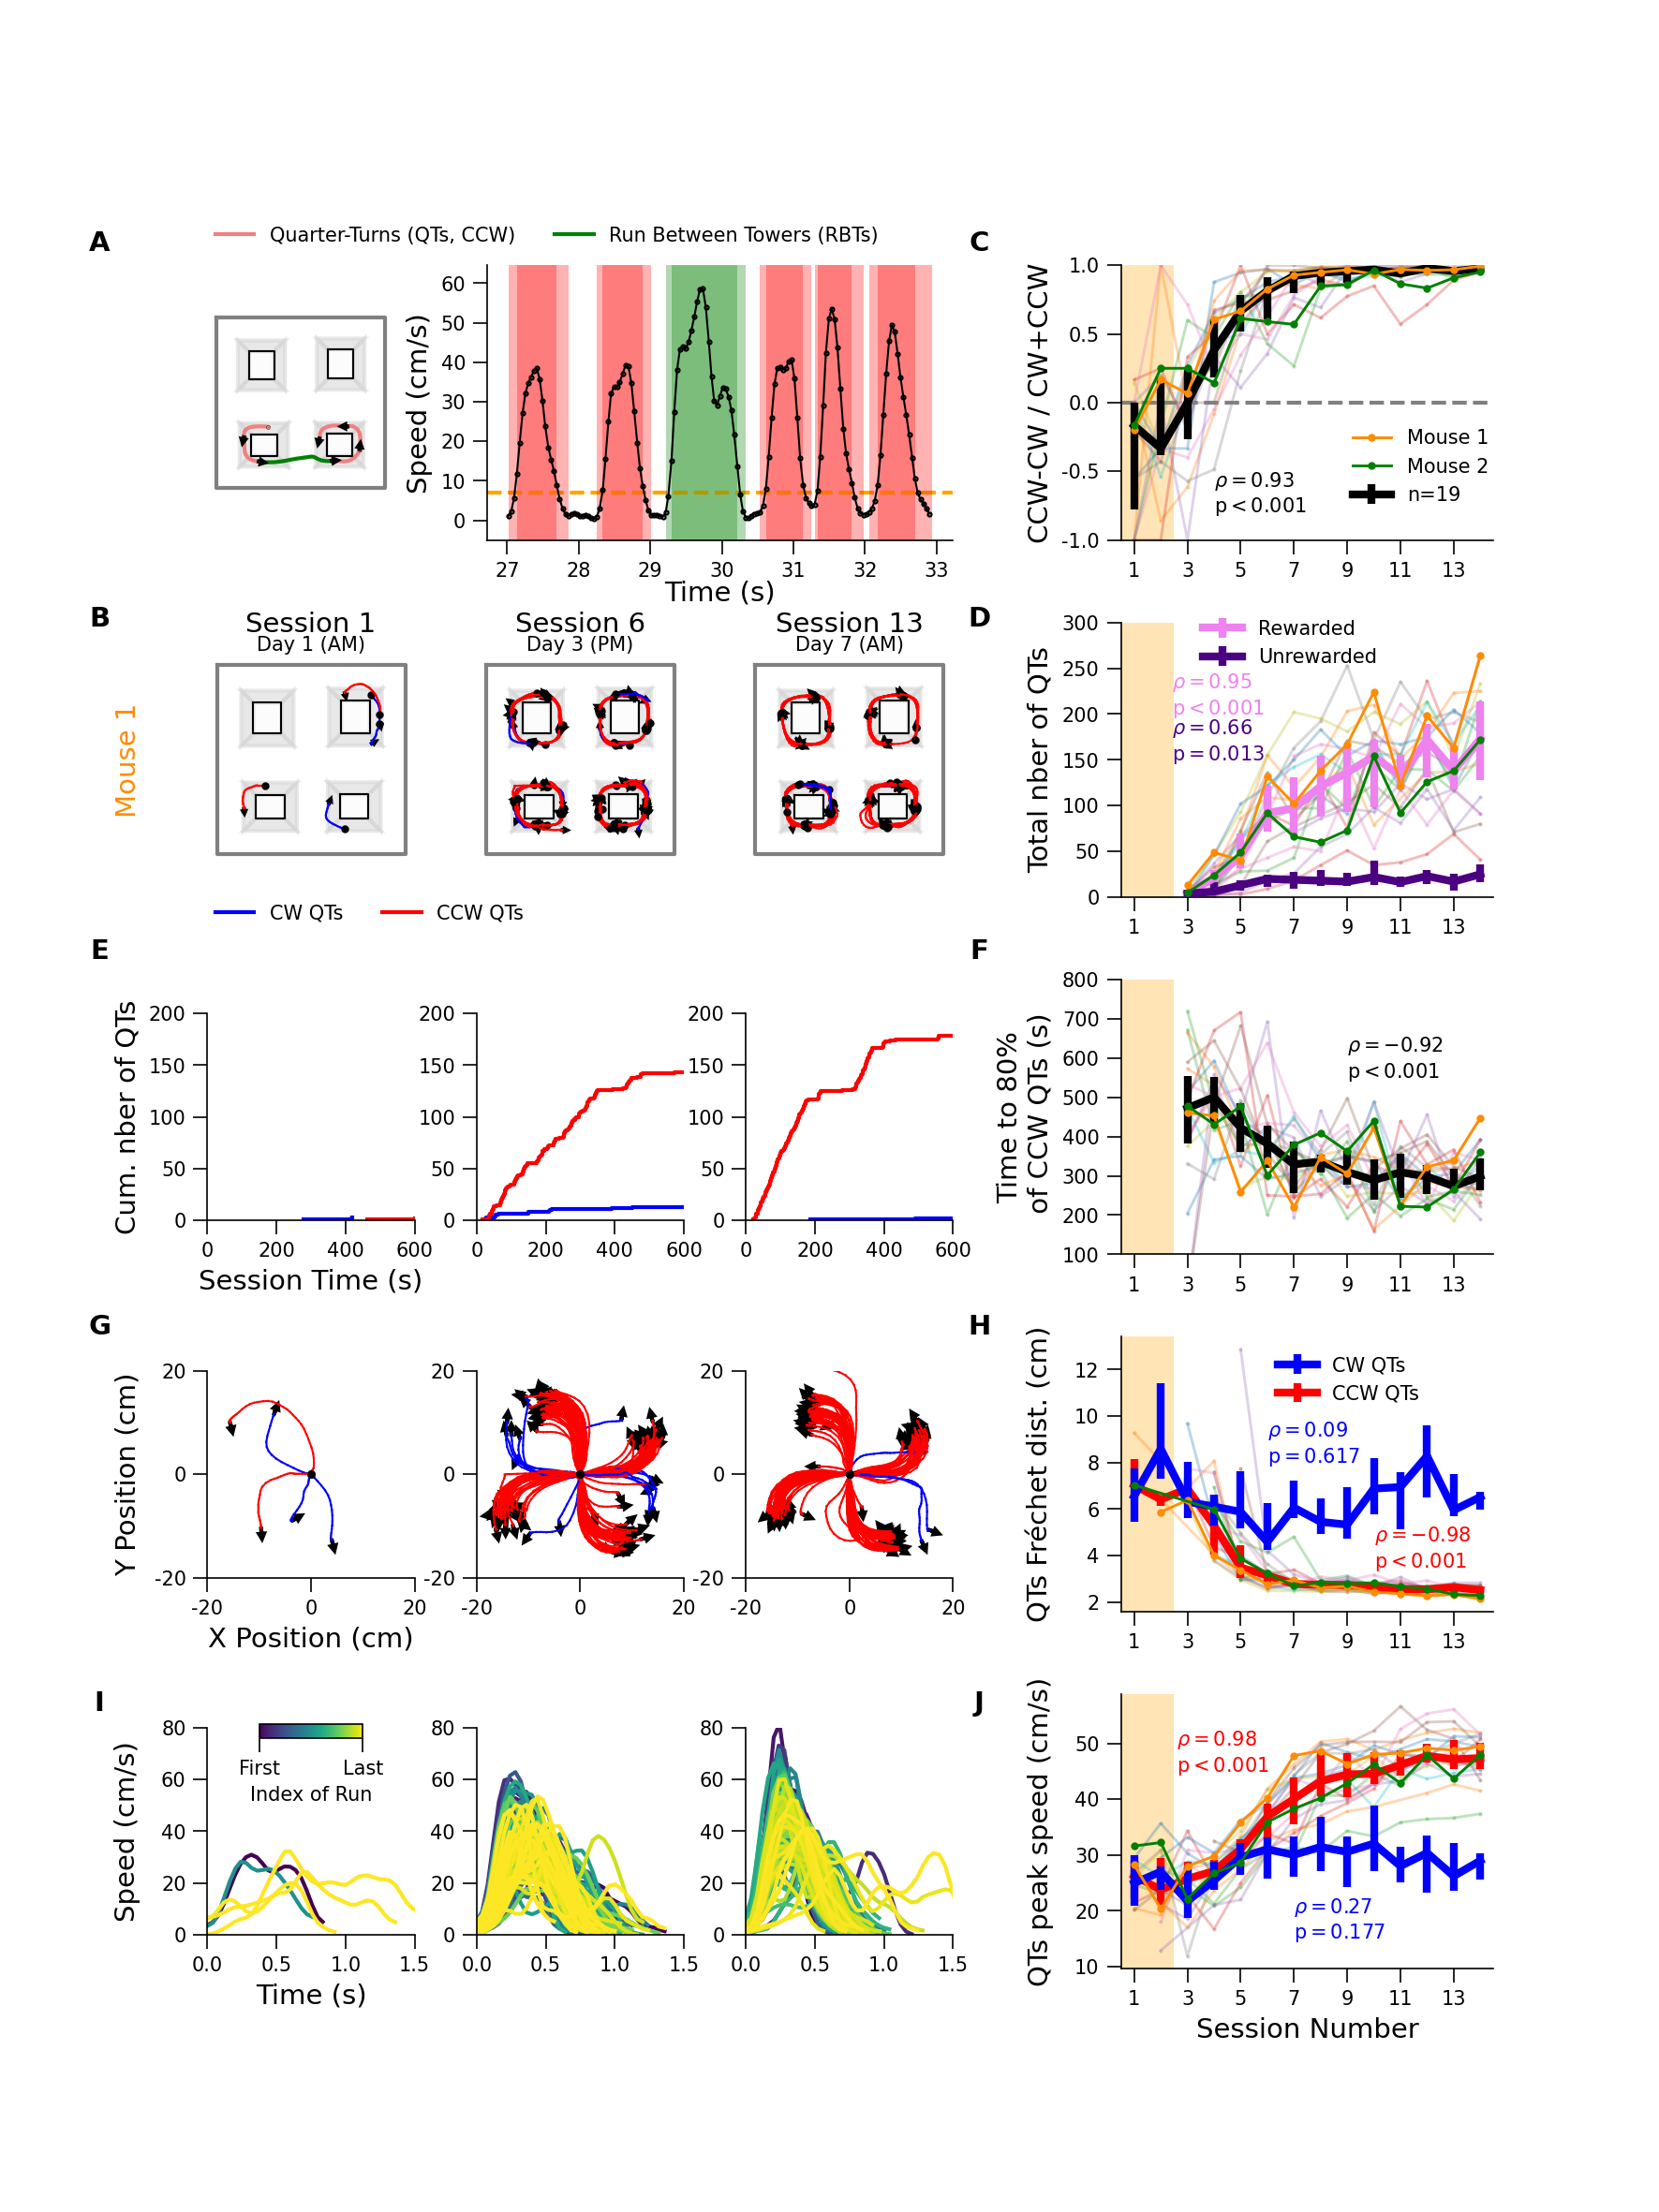

In [28]:
from IPython.display import display
from PIL import Image

# Load and display the image
img = Image.open("Figure03.png")
display(img)



# 1. Importing necessary libraries and general functions  

In [2]:
import os
import glob
from processing_TowerCoordinates import *
from processing_session_trajectory import *
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.path as mpath
import matplotlib.cm as cm
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import numpy as np
import pickle
import scipy.ndimage as ndimage
from scipy.stats import wilcoxon
from processing_TowerCoordinates import *
from datetime import date
from scipy.ndimage import gaussian_filter as smooth
import matplotlib.colors as mcolors
import similaritymeasures as sm
from bisect import bisect
from scipy.stats import spearmanr

import warnings 
from matplotlib.colors import LinearSegmentedColormap


plt.style.use('paper.mplstyle')

# useful line to interupt Run all execution
# raise SystemExit("Stopping execution here.")


In [3]:
plotintermediatesteps = False 

# 2. Select mice that will be analysed in the figure
### Define the data_folder where your MOU* folders are, enter the list of mice (MOU* folders), define the sessions that will be used for each animals

In [4]:
# defining data folder path and mice list

# path_to_data_folder is the path of the folder where you store the folders of your different mice.

path_to_data_folder='/LocalData/ForagingMice/4TowersTaskMethodPaper_Data/Group1Data/'
# path_to_data_folder = '/Users/davidrobbe/Documents/Science/Data/ForagingMice/Group1Data/'
# path_to_data_folder='/home/david/MyLocalData/4TowersTask_MethodPaper/Group1Data'

# Analysing the entire group of mice
mice_to_analyse = [
    "MOUEml1_5", "MOUEml1_8", "MOUEml1_11", "MOUEml1_12", "MOUEml1_13", "MOUEml1_15", "MOUEml1_18", "MOUEml1_20",
    "MOURhoA_2", "MOURhoA_5", "MOURhoA_6", "MOURhoA_8", "MOURhoA_9", "MOURhoA_12", "MOURhoA_14",
    "MOUB6NN_4", "MOUB6NN_6", "MOUB6NN_13", "MOUB6NN_15"
]

# Verify that all folders in mice_to_analyse are present in path_to_data_folder
missing_folders = [mouse for mouse in mice_to_analyse if not os.path.isdir(os.path.join(path_to_data_folder, mouse))]

if missing_folders:
    print("Missing mice folders:", missing_folders)
else:
    print("All mice folders are present in data folder.")

# Print the number of mice, the list of mice
print(f' {len(mice_to_analyse)} {"mice" if len(mice_to_analyse) > 1 else "mouse"} will be analysed\n')

# Select the number of sessions that will be analysed for each mice knowing the analysis starts with the first session (familiarisation)
first_and_last_session_indexes = [0,14]

# Setting the seed for random processes used in statistics
seed = 27
np.random.seed(seed)

# Select the offset to apply to the number of the sessions when plotting. By default, it is equal to the number of the first session.
# It resulsts in sessions being named respectively to their actual positions in the data set. TODO: Should reformulate this 
session_index_offset = first_and_last_session_indexes[0]


All mice folders are present in data folder.
 19 mice will be analysed



# 3. Chosing illustration mouse and sessions  

In [5]:
# Chose the 2 mice that are highlighted in statistics across figures
illustration_mice = ['MOUEml1_8', 'MOUEml1_5']

# Chose the color with which the illustration mice will highlighted with
illustration_colors = ['darkorange', 'green']


# Mouse that will be used as single example in this figure to show QTs trajectories and kinematics 
example_mouse_index = 0
example_mouse_bis_index = 1
example_mouse = illustration_mice[example_mouse_index]
example_mouse_bis = illustration_mice[example_mouse_bis_index]

# Chosing index of the sessions to show as examples. They are chosen by their index (session 0 is the first session etc.)
illustration_sessions_indexes = [0, 5, 12]

# coordinates in cm of the external walls of the arena
arena_coordinates_cm = [[4.5, 88.86], [90.3, 88.86], [90.3, 2.7], [4.5, 2.7]]

# Set the limits of the x-axis on the statistics plots
xlim_stats = [first_and_last_session_indexes[0]+0.5,first_and_last_session_indexes[1]+0.5]


# 4. General functions

In [6]:
def get_day_and_period(session_idx):
    day = session_idx // 2 + 1
    period = 'AM' if session_idx % 2 == 0 else 'PM'
    return day, period

def force_aspect(ax, ratio=1):
    """
    Force the aspect ratio of the given axis (ax) to a specific ratio.
    The ratio parameter allows scaling of the aspect ratio. Default is 1.
    
    Arguments:
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        ratio (float, optional): Ratio of the figure's dimensions
    
    """
    
    ratio = 1.0  # Set ratio to 1.0, making the aspect ratio 1:1 by default
    
    # Get the current limits of the x and y axes
    x_left, x_right = ax.get_xlim()  # Get the left and right x-axis limits
    y_low, y_high = ax.get_ylim()    # Get the lower and upper y-axis limits
    
    # Calculate the new aspect ratio and set it
    # The formula is the absolute ratio of the width and height, adjusted by the given ratio
    ax.set_aspect(abs((x_right - x_left) / (y_low - y_high)) * ratio)

def cm2inch(value):

    """
    Converts centimeters to inches for figure size.

    Arguments:
        value (float): value to convert in cm 

    """

    return value/2.54

def filter_qts(qts):

    """
    Filter out QTs with length above threshold and during which more than 1 switch occured.

    Arguments:
        qts (list): list of QTs (in the original format from the pickle)

    return:
        (list): list of filtered QTs
    """

    filtered_qts = []

    
    for qt in qts:

        # Skip current QT if there is more than 1 switches
        if qt[3]['num_trapezeswitch']!=1:
            
            continue
        
        # Skip current QT if it is longer than a threshold length (30 cm)
        if qt[4]['epoch_distance']>30:

            continue

        # Keep current QT if it did not check the removal conditions
        filtered_qts.append(qt)

    return filtered_qts

def count_qts(qts):

    total_qts = len(qts)
    cw_qts = 0
    rewarded_qts = 0

    for qt in qts:

        if qt[3]['direction']=='CW':

            cw_qts += 1

        if qt[3]['Rewarded']:

            rewarded_qts += 1

    return total_qts, cw_qts, rewarded_qts

def compute_average_direction(points):

    """
    Compute the average direction of a trajectory portion, assuming the coordinates are in chronological order.

    Arguments:
        points (2D numpy.array): Trajectory of which the average direction will be computed

    Outputs:
        avg_diff (1D numpy.array): vector pointing to the average direction
        angle (float): angle of the vector with the x-axis 
    """
    
    diffs = np.diff(points, axis=0)
    avg_diff = np.mean(diffs, axis=0)
    angle = np.arctan2(avg_diff[1], avg_diff[0])
    return avg_diff, angle

def finding_mouse_rewarded_direction(folder_path_mouse_to_process, session_index):
    
    """
    Determines the rewarded direction for the session corresponding to the input index of a given mouse. 
    This index is relative to the session position in the series of analysed sessions.
    This input index can have an offset. This is usefull if the sessions series analysed does not start with the first session. 
    
    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse sessions folders.
        session_index (int): Index of the session that will be used to define the rewarded direction

    Returns:
        str: 'CW' (Clockwise) if the rewarded direction is 270 degrees,
             'CCW' (Counterclockwise) if the rewarded direction is 90 degrees,
             numpy.nan if reward delivery is not allowed 
             None if an error occurs or if both directions are rewarded.
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # Load data from the last session
    session_traj_df, session_turns_df, session_param_df = load_data(folder_path_mouse_to_process, sessions_to_process[session_index])

    # Extract rewarded direction in degrees
    rewarded_direction_degrees = session_param_df["potentialRewardedDirections"][0]

    # Check if reward delivery is allowed
    if session_param_df["allowRewardDelivery"][0]:

        # Determine the rewarded direction based on the extracted value
        if rewarded_direction_degrees == '[270]':
            rewarded_direction = 'CW'  # Clockwise

        elif rewarded_direction_degrees == '[90]':
            rewarded_direction = 'CCW'  # Counterclockwise
        
        elif rewarded_direction_degrees == '[90, 270]':
            rewarded_direction = 'both'  # Clockwise and Counterclockwise

        # Returns None if the rewarded direction entry in session_param_df is not recognized
        else:
            print('ERROR: Unexpected rewarded direction value:', rewarded_direction_degrees)
            return None  # Explicitly return None to indicate failure
    
    else:

        # Rewarded direction is set to X if reward delivery os not allowed
        rewarded_direction = 'X'

    return rewarded_direction

def plot_learning_curves(mouse_metric_persession, ax, mice_list=None, mice_to_highlight=[], mice_to_highlight_labels=[None,None], highlight_colors = ["darkorange", "green"], show_individual_mice=True,
                         median_color='black', show_xlabel=True, ylabel='', main_line_label=None, show_fam=False, 
                         tick_interval=1, index_offset=0, xlim=[None,None], ylim=None, show_legend=True, legend_loc=(0.05, 0.9)):
    """
    Plots a given metric across sessions for multiple mice (also called a learning curves).

    Arguments:
        mouse_metric_persession (dict): Dictionary where keys are mouse IDs and values are lists of (session_index, value) lists.
        mice_list (list, optional): List of mice to include in the plot. Defaults to all mice in the mouse_metric_persession.
        mice_to_highlight (list, optional): List of up to two mice IDs to highlight with distinct colors.
        mice_to_highlight_labels (list, optional): List of the label of the mice to highlight.
        show_individual_mice (bool): If true, plot a line for each individual mouse.
        ax (matplotlib.axes.Axes): Axes object for plotting.
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        ylabel (str, optional): Label for the y-axis.
        main_line_label (str, optional): Label of the median and quartiles range.
        show_fam (bool): Toggle the display of familiarization sessions label
        tick_interval (int, optional): Interval for x-axis tick marks. Defaults to 1.
        index_offset (int, optional): Offset to apply to the numbers in the x axis. Use it if you want to the first sessions to be named '1'.
        xlim (tuple, optional): Tuple specifying x-axis limits. Defaults to None.
        ylim (tuple, optional): Tuple specifying y-axis limits. Defaults to None.
        show_legend (bool, optional): Whether to show the legend. Defaults to True.
        legend_loc (tupple, optional): Location of the legend.
    """

    # If no mice are specified, use all available mice
    if mice_list is None:
        mice_list = list(mouse_metric_persession.keys())

    all_session_indices = set()  # Track all session indices across selected mice
    values_per_session = {}  # Store values for each session across mice

    mice_to_plot = copy.deepcopy(mice_list)

    # Ensure that the mice to hihlight will be plotted and displayed on the legend in order
    if len(mice_to_highlight)>0:

        mice_to_plot.remove(mice_to_highlight[0])
        mice_to_plot.remove(mice_to_highlight[1])

        mice_to_plot = mice_to_highlight + mice_to_plot
    
    # Loop through each mouse and gather session data

    for mouse in mice_to_plot:

        if mouse not in mouse_metric_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting the sub-list of sessions to analyse
        sessions = mouse_metric_persession[mouse]

        # Extract session indices and corresponding values
        session_indices = [session[0] for session in sessions]
        values = [session[1] for session in sessions]

        # Check if there is a nan value in the values list and remove it to allow plotting of lines between points with values
        if sum(np.isnan(x) for x in values)>0:

            session_indices_array=np.array(session_indices)
            values_array=np.array(values)
            mask = ~np.isnan(values_array)
            session_indices=session_indices_array[mask]
            values=values_array[mask]

        # Plot learning curves for each mouse if show_individual_mice is True
        if show_individual_mice:

            if mouse == mice_to_highlight[0]:
                color = highlight_colors[0]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[0], zorder=100*len(median_color))

            elif mouse == mice_to_highlight[1]: 
                color = highlight_colors[1]
                ax.plot(np.array(session_indices)+index_offset, values, color=color, marker='o', linewidth=0.7, 
                        markersize=1, label= mice_to_highlight_labels[1], zorder=100*len(median_color))
            
            else:
                ax.plot(np.array(session_indices)+index_offset, values, marker='o', linewidth=0.7, markersize=1, alpha=0.3, markeredgewidth=0.0)

        # Update session index tracking
        all_session_indices.update(session_indices)
        for session, value in sessions:
            if session not in values_per_session:
                values_per_session[session] = []
            values_per_session[session].append(value)

    # Convert session indices to a sorted list
    sorted_sessions = sorted(all_session_indices)

    # Compute median and 25th-75th percentile range for each session
    median_values = []
    lower_quartile = []
    upper_quartile = []

    for session in sorted_sessions:
        session_values = values_per_session[session]
        median_values.append(np.nanmedian(session_values))
        lower_quartile.append(np.nanpercentile(session_values, 25))
        upper_quartile.append(np.nanpercentile(session_values, 75))

    median_values = np.array(median_values)
    lower_quartile = np.array(lower_quartile)
    upper_quartile = np.array(upper_quartile)

    # If the median and quartiles range don't have a label, give them a default label.
    if not main_line_label:

        main_line_label = f'Median \u00B1 Quartiles, n={len(mice_list)}'

    # Plot median learning curve with shaded 25th-75th percentile range
    ax.errorbar(np.array(sorted_sessions)+index_offset, median_values, yerr=[median_values-lower_quartile, upper_quartile-median_values], alpha=1, color=median_color, linewidth = 2, label=main_line_label, zorder=50*len(median_color))

    # Set axis labels and formatting
    if show_xlabel:
        ax.set_xlabel('Session Number', fontsize=7)
    
    ax.set_ylabel(ylabel, fontsize=7)

    # Ensure x-axis labels are integers
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    # Set x-ticks at specified intervals
    if all_session_indices:
        max_index = max(all_session_indices)
        ax.set_xticks(range(1+index_offset, max_index + 1+index_offset, tick_interval))

    # Apply x and y axis limits if provided
    if xlim is not None:
        ax.set_xlim(xlim)
    
    if ylim is not None:
        ax.set_ylim(ylim)

    ylimits = ax.get_ylim()  # Get the current y-limits
    rectangle_height = abs(ylimits[1]-ylimits[0])  # Calculate the height of the rectangle


    # Define the rectangle position and size
    rect = patches.Rectangle((0.5, ylimits[0]), 2, rectangle_height, color='moccasin', alpha=1, lw=0, zorder=-np.inf)  # (x_start, y_start), width, height

    # Add rectangle to the plot
    ax.add_patch(rect)

    if show_fam:
        # Add text label on top of the rectangle
        ax.text(1.5, ylimits[1], "Fam.", fontsize=6, ha='center', va='bottom', fontweight='normal',color='orange', alpha=0.6)

    # Show legend if required
    if show_legend:

        ax.legend(frameon=False, loc=legend_loc, )


def shuffled_spearman_test(mouse_values_persession, shuffle_number, hypothesis, illustration_mouse_name = None, first_and_last_session_indexes=[None,None]):
    
    """
    Compute the Spearman correlation coefficient of input session-wise data then compare it to a null distribution computed by shuffling
    the input data several times

    Arguments:
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    Return:
        (list): list containing the Spearman correlation coefficient of the unshuffled data and the p-value associaed to the test
    """

    # Selecting mice to analyse
    if illustration_mouse_name is None:
        illustration_mouse_name = list(mouse_values_persession.keys())

    ### Compute the Spearman correlation coefficient distribution by shuffling data ###

    # Initialize the list where the Spearman correlation coefficients from shuffled data will be stored. 
    # This will be the null distribution of Spearman correlation coefficient
    spearman_rho_list = []
    
    # Shuffle the data shuffle_number times
    for _ in range(shuffle_number):

        # Initialize the list that will contain shuffled data
        shuffled_values_list = []
        
        # Iterate on every mice
        for mouse in illustration_mouse_name:

            # Checking if the current mouse has no value to plot
            if mouse not in mouse_values_persession:
                print(f"Mouse {mouse} not found in data. Skipping.")
                continue    

            # Selecting sessions under the limit
            sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

            # Extract sessions number
            session_indices = [session[0] for session in sessions]
            # Extract and shuffle values 
            shuffled_values = np.random.choice([session[1] for session in sessions], size=len(sessions), replace=False)
            # Store the shuffled values
            shuffled_values_list.append(shuffled_values)

        # Compute the median over all the mice
        median_values = np.nanmedian(shuffled_values_list,axis=0)
        # Compute the Spearman correlation coefficient of the median
        spearman_result = spearmanr(session_indices, median_values)
        # Store the coefficient
        spearman_rho_list.append(spearman_result[0])
    
    ### Compute the Spearman correlation coefficient of unshuffled data ###

    values_list = []

    for mouse in illustration_mouse_name:

        # Checking if the current mouse has no value to plot
        if mouse not in mouse_values_persession:
            print(f"Mouse {mouse} not found in data. Skipping.")
            continue    

        # Selecting sessions under the limit
        sessions = copy.deepcopy(mouse_values_persession[mouse][first_and_last_session_indexes[0]:first_and_last_session_indexes[1]])

        # Extract sessions number
        session_indices = [session[0] for session in sessions]

        # Extract values
        values = [session[1] for session in sessions]
        
        # Store the value
        values_list.append(values)

    # Compute the median over all the mice
    actual_median_values = np.nanmedian(values_list,axis=0)

    # Compute the Spearman correlation coefficient of the median
    actual_spearman_result = spearmanr(session_indices,actual_median_values, nan_policy='omit')
    actual_rho = actual_spearman_result[0]

    # Compute the p-value corresponding to the tested hypothesis
    if hypothesis=="increasing":
        # Computing the the proportion of the null distribution above the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[bisect(np.sort(spearman_rho_list), actual_rho):])/len(spearman_rho_list)
    elif hypothesis=="decreasing":
        # Computing the the proportion of the null distribution below the correlation coefficient of unshuffled data. This is the p-value
        p_value = len(spearman_rho_list[:bisect(np.sort(spearman_rho_list), actual_rho)])/len(spearman_rho_list)
    else:
        # Raise an error if no valid hypothesis was made
        print("ERROR : Invalid hypothesis. Please specify increasing or decreasing")
        return

    return actual_rho, p_value

def plot_shuffled_spearman_test_res(ax, text_loc, mouse_values_persession, n_shuffles, hypothesis, color='black', illustration_mouse_name=None, first_and_last_session_indexes=[1,None]):

    """
    Plots the result of shuffled_spearman_test as a text on a figure.

    Arguments:
        ax (matplotlib.axes.Axes): Axes object for plotting
        text_loc (list): coordinate of the text (in data units)
        mouse_values_persession (dict): Dictionary with session numbers as keys and the corresponding values as entries
        shuffle_number (int): Number of time the data will be shuffled and the corresponding correlation coefficient computed 
        hypothesis (string): Hypothesis tested, whether the values sequence is increasing or decreasing across sessions
        color (str): Color of the text
        illustration_mouse_name (list, optional): List of mice from mouse_values_persession to use
        first_and_last_session_indexes (list, optional): List containing indexes of first and last session to plot
    
    """

    test_res = shuffled_spearman_test(mouse_values_persession, n_shuffles, hypothesis, illustration_mouse_name=illustration_mouse_name, first_and_last_session_indexes=first_and_last_session_indexes)    

    if test_res[1]==0:
        
        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ < 0.001$', fontsize=5, color=color) 

    else:

        ax.text(text_loc[0],text_loc[1],rf'$\rho = {round(test_res[0],2)}$' + '\n' + rf'p$ = {round(test_res[1],3)}$', fontsize=5, color=color)

# 5. Computations for panel B, D and J statistics

The next two functions are used to:
- Find the times at which QTs occured.
- Find the time at which the number of QTs becomes higher than a given threshold. (not clear)

In [7]:
def cumulated_turns_time_profile(folder_path_mouse_to_process, session_to_process, rewarded_direction):
    """
    Computes the cumulative number of runs around a tower at each time a new run around a tower occurs, for a given session and a given mouse.

    Arguments:
        folder_path_mouse_to_process (str): Path to the folder containing mouse session data.
        session_to_process (str): Name of the session to be processed.
        reference_session_index (int): Index of the session that will be used to define the rewarded direction
        
    Returns:
        tuple: Two lists containing:
            - (good_turns_time, cumulated_good_turns): Sorted times and cumulative counts for turns in rewarding direction.
            - (bad_turns_time, cumulated_bad_turns): Sorted times and cumulative counts for turns in non-rewarded direction.
    """

    # Construct the path to the session pickle file
    output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

    # Load session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Deep copy the list of turn epochs
    runs_around_tower = filter_qts(copy.deepcopy(session_data['all_epochs']['run_around_tower']))

    # Initialize lists to store filtered turns
    time_of_runsaroundtower_cw = []
    time_of_runsaroundtower_ccw = []

    # Iterate through each recorded turn around the tower
    for run_around_tower in runs_around_tower:

        # Categorize turns based on direction
        if run_around_tower[3]['direction'] == 'CW':
            time_of_runsaroundtower_cw.append(run_around_tower[4]['epoch_time'])
        elif run_around_tower[3]['direction'] == 'CCW':
            time_of_runsaroundtower_ccw.append(run_around_tower[4]['epoch_time'])

    # Sort the turn times for cumulative calculations
    CW_times_sorted = np.sort(time_of_runsaroundtower_cw)
    CCW_times_sorted = np.sort(time_of_runsaroundtower_ccw)

    # Compute cumulative counts for each direction
    CW_cumulative = np.arange(1, len(CW_times_sorted) + 1)
    CCW_cumulative = np.arange(1, len(CCW_times_sorted) + 1)
    
    # Assign good and bad turns based on the rewarded direction
    if rewarded_direction == 'CW':
        good_turns_time = CW_times_sorted
        bad_turns_time = CCW_times_sorted
        cumulated_good_turns = CW_cumulative
        cumulated_bad_turns = CCW_cumulative

    elif rewarded_direction == 'CCW':
        good_turns_time = CCW_times_sorted
        bad_turns_time = CW_times_sorted
        cumulated_good_turns = CCW_cumulative
        cumulated_bad_turns = CW_cumulative

    elif rewarded_direction == 'X':

        good_turns_time = np.ones(len(CCW_times_sorted))*np.nan
        bad_turns_time = np.ones(len(CW_times_sorted))*np.nan
        cumulated_good_turns = np.ones(len(CCW_cumulative))*np.nan
        cumulated_bad_turns = np.ones(len(CW_cumulative))*np.nan

    else:
        print('ERROR: Unexpected rewarded direction value')
        return None  # Explicitly return None to indicate an error

    return [good_turns_time, cumulated_good_turns], [bad_turns_time, cumulated_bad_turns]

def accumulation_threshold(cummulated_events_time, threshold_fraction=0.8):

    """
    Compute the first time point at which the cummulated number of event in cummulated_events_time
    is above a threshold, that is a fraction (80% by default) of the total number of events.
    
    Arguments:
        cummulated_events_time (list): list of time at which one event occurs.
        threshold_fraction (float, optional): fraction of the total number of event that will used as threshold. 

    Returns:
        float: first value in cummulated_events_time that is above the
        
    """

    # Compute the total number of events
    total_events = len(cummulated_events_time)

    # Initialise index of the first event
    i = 0

    # Compute the fraction of cummulated events
    fraction_of_events = (i+1)/total_events if total_events!=0 else 0

    # Iterate while the fraction of cummulated events is lower than the threshold fraction 
    while fraction_of_events<threshold_fraction and total_events!=0:

        # Increase the index
        i = i + 1
        # Update the fraction of cummulated events at the new index
        fraction_of_events = (i+1)/total_events

    res = cummulated_events_time[i] if total_events!=0 else 0
    
    # Return the first time in cummulated_events_time at which the fraction of cummulated events is higher than threshold_fraction.  
    return res

### Here will be computed and stored metrics related to the number of QTs that will be plotted for each mouse across sessions. Those metrics are:
- The number of turns in rewarding direction
- The ratio of the difference of the number of CCW and CW turns with respect to the total number of turns. We call it the CCW vs CW normalized difference.    
$ \frac{N_{CCW}-N_{CW}}{N_{CCW}+N_{CW}} $
- The time that the mouse took to perform 80% of the total number of turns in rewarded direction of the session. 

In [8]:
# Initialize dictionaries to store the various metrics for each mouse
mice_rewarded_qts_persession = {mouse: [] for mouse in mice_to_analyse}
mice_unrewarded_qts_persession = {mouse: [] for mouse in mice_to_analyse}
mice_ccw_vs_cw_norm_diff_persession = {mouse: [] for mouse in mice_to_analyse}

mice_qts_rewarded_dir_threshold_persession = {mouse: [] for mouse in mice_to_analyse}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')


    # Process each session for the current mouse
    for session_index, session_to_process in enumerate(sessions_to_process):

        
        # Define the pickle file path for the session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            # Append session Nan data to the respective dictionaries
            mice_ccw_vs_cw_norm_diff_persession[mouse].append([session_index + 1, np.nan])
            mice_rewarded_qts_persession[mouse].append([session_index + 1, np.nan])
            mice_unrewarded_qts_persession[mouse].append([session_index + 1, np.nan])
            mice_qts_rewarded_dir_threshold_persession[mouse].append([session_index + 1, np.nan])
            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Determine the rewarded direction for all sessions of the current mouse
        rewarded_direction = finding_mouse_rewarded_direction(folder_path_mouse_to_process, first_and_last_session_indexes[0]+session_index)
        
        # Extract run around tower results from the session data
        
        epochs = session_data['all_epochs']
        qts = filter_qts(epochs['run_around_tower'])
        total_qts, cw_qts, rewarded_qts = count_qts(qts)
        ccw_qts = total_qts - cw_qts
        ccw_vs_cw_norm_diff = (ccw_qts-cw_qts)/(total_qts) if total_qts!=0 else 0

        # Compute cumulated turns time profiles for turns in rewarded and unrewarded direction, if there is a unique rewarded direction
            
        [rewarded_dir_turns_time, cumulated_rewarded_dir_turns], [unrewarded_dir_turns_time, cumulated_unrewarded_dir_turns] = cumulated_turns_time_profile(folder_path_mouse_to_process, session_to_process, rewarded_direction)

        # Determine the rewarded direction turns threshold time
        rewarded_dir_turns_threshold_time = accumulation_threshold(rewarded_dir_turns_time)

        # If reward delivery is not allowed, set to numpy.nan the metrics values concerning rewarded direction
        if rewarded_direction == 'X':
           
            # Append session data to the respective dictionaries
            mice_ccw_vs_cw_norm_diff_persession[mouse].append([session_index + 1, ccw_vs_cw_norm_diff])
            mice_rewarded_qts_persession[mouse].append([session_index + 1, np.nan])
            mice_unrewarded_qts_persession[mouse].append([session_index + 1, np.nan])
            mice_qts_rewarded_dir_threshold_persession[mouse].append([session_index + 1, np.nan])

        else:        

            # Append session data to the respective dictionaries
            mice_ccw_vs_cw_norm_diff_persession[mouse].append([session_index + 1, ccw_vs_cw_norm_diff])
            mice_rewarded_qts_persession[mouse].append([session_index + 1, rewarded_qts])
            mice_unrewarded_qts_persession[mouse].append([session_index + 1, total_qts-rewarded_qts])
            mice_qts_rewarded_dir_threshold_persession[mouse].append([session_index + 1, rewarded_dir_turns_threshold_time])


Mouse MOUEml1_5. There is/are 14 sessions:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615'] 

Mouse MOUEml1_8. There is/are 14 sessions:
['MOUEml1_8_20230420-1740', 'MOUEml1_8_20230421-1132', 'MOUEml1_8_20230422-1145', 'MOUEml1_8_20230422-1748', 'MOUEml1_8_20230423-1156', 'MOUEml1_8_20230423-1725', 'MOUEml1_8_20230424-1118', 'MOUEml1_8_20230424-1724', 'MOUEml1_8_20230425-1119', 'MOUEml1_8_20230425-1740', 'MOUEml1_8_20230426-1137', 'MOUEml1_8_20230426-1720', 'MOUEml1_8_20230427-1146', 'MOUEml1_8_20230427-1708'] 

Mouse MOUEml1_11. There is/are 14 sessions:
['MOUEml1_11_20230420-1906', 'MOUEml1_11_20230421-1239', 'MOUEml1_11_20230422-1250', 'MOUEml1_11_20230422-18

# 6. Computations for panel F

### The following cells will be used to compute the median of the median Fréchet distance of each pair of flattened trajectories;

In [9]:
def towers_coordinates_as_dictionnary(towers_coordinates_cm):
    
    """
    Converts a dictionary of tower coordinates into a structured dictionary 
    where each tower's coordinates are labeled with explicit corner names.

    Arguments:
        towers_coordinates_cm (dict): Dictionary where keys are tower names and 
                                      values are lists/tuples of four coordinates.

    Returns:
        dict: A dictionary mapping tower names to their respective coordinates, 
              labeled as 'NW' (North-West), 'NE' (North-East), 'SE' (South-East), 
              and 'SW' (South-West).
    """

    # Initialize a dictionary to store labeled coordinates
    towers_coordinates_as_dict = {}

    # Predefined corner names in the order expected from input coordinates
    corner_names = ['NW', 'NE', 'SE', 'SW']

    # Map each tower's coordinates to its corresponding corner names
    for tower, coordinates in towers_coordinates_cm.items():
        towers_coordinates_as_dict[tower] = {
            corner_names[i]: coord for i, coord in enumerate(coordinates)
        }

    return towers_coordinates_as_dict

def get_tower_and_corner(run_around_tower):

    """
    Get the label of the tower and corner around wich the run around tower is happened
    based on the second and third elements saved in run_around_tower: 'N' for north, 'S' for south, 'E' for east, 'W' for west.
    
    Argument:
        run_around_tower (list): a list containing information about a run around tower

    Returns:
        str: Name of the tower around which the run occured
        str: A two character string. The first character is the name of the starting trapeze,
             the last character is the name of the ending trapeze  
    """
    
    # Extract tower name, starting name and ending trapeze name 
    tower_name = run_around_tower[1][0]
    start_trapeze = run_around_tower[1][1]
    end_trapeze = run_around_tower[2][1]
    
    # Determine the corner based on the start and end faces
    if start_trapeze == 'W' and end_trapeze == 'S':
        corner = 'SW'
    elif start_trapeze == 'S' and end_trapeze == 'E':
        corner = 'SE'
    elif start_trapeze == 'E' and end_trapeze == 'N':
        corner = 'NE'
    elif start_trapeze == 'N' and end_trapeze == 'W':
        corner = 'NW'
    elif start_trapeze == 'W' and end_trapeze == 'N':
        corner = 'NW'
    elif start_trapeze == 'N' and end_trapeze == 'E':
        corner = 'NE'
    elif start_trapeze == 'E' and end_trapeze == 'S':
        corner = 'SE'
    elif start_trapeze == 'S' and end_trapeze == 'W':
        corner = 'SW'
    else:
        corner = None  # Handle unexpected cases
    
    return tower_name, corner

def rotate_sw_trajectory_90_ccw(trajectory):
    
    """
    Rotates the input trajectory of 90° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 90° counter-clockwise

    """
    
    # Define the roation matrix
    rotation_matrix = np.array([[0, -1], [1, 0]])
    
    # Returns the matrix product of the rotation matrix and the trajectory 
    return rotation_matrix @ trajectory

def rotate_nw_trajectory_180_ccw(trajectory):

    """
    Rotates the input trajectory of 180° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 180° counter-clockwise

    """

    return -trajectory

def rotate_ne_trajectory_270_ccw(trajectory):
    
    """
    Rotates the input trajectory of 270° in counter-clockwise direction.

    Argument:
        trajectory (numpy.ndarray): A 2D numpy.ndarray of shape (2, X).

    Returns:
        numpy.ndarray: trajectory rotated by 270° counter-clockwise

    """
    
    # Define the roation matrix
    rotation_matrix = np.array([[0, 1], [-1, 0]])

    # Returns the matrix product of the rotation matrix and the trajectory 
    return rotation_matrix @ trajectory

def compute_frechet_distances(runs_list):

    """
    This function takes a list of trajectories of dimensions (2,N), computes the Fréchet distance 
    between each pairs of trajectories, and returns the median of those distances.
    
    Arguments:
        runs_list (list): List of trajectories of dimensions (2,N)

    Return:
        (float): Median of the Fréchet distances of all trajectories pairs
    
    """

    # Create an empty list that will contain the Fréchet distances of all trajectories pairs
    frechet_distances_list = []

    # Iterate on all trajectories
    for i in range(len(runs_list)):

        # Transpose the trajectory
        # This step is necessary as the function that computes the Fréchet distance takes as an argument trajectories of dimensions (N,2)
        traj_points_a = np.transpose(runs_list[i])

        # Iterate on every trajectories of higher ranks to create trajectories pairs
        # We do that so that no pairs is counted twice, as the Fréchet distance between trajectory A and B is the same as between B and A
        for j in range(i+1, len(runs_list)):

            # Transpose the trajectory
            traj_points_b = np.transpose(runs_list[j])

            # Compute the Fréchet distance for the current pair of trajectories
            frechet_distance = sm.frechet_dist(traj_points_a,traj_points_b)

            # Store the result in a list
            frechet_distances_list.append(frechet_distance)

    # Return the median of the list of Fréchet distances
    return frechet_distances_list


### This cell process the runs around tower trajectory such that:
- All runs around tower with the same starting and ending trapeze and are shifted to have their origin on the same axis, independently of the tower where they occur.
- All runs around tower are rotated from 90°/180°/270° counter-clockwise when the corner around which the mouse turns is South-West/North-West/North-East.
- Does so separately for turns in clockwise and counter-clockwise direction.

In [10]:
# Initialize a dictionary to store all trajectories for each mouse, with empty lists for each session
mice_alltrajectories_persession = {mouse: {} for mouse in mice_to_analyse}

# Initialize a dictionary to store realigned and rotated trajectories for each mouse, with empty dictionaries for each session
trajectories_per_session_realigned_rotated = {mouse: {} for mouse in mice_to_analyse}

# Loop through each mouse in the list of mice to realign all their turns trajectory
for mouse in mice_to_analyse:
    # Define the folder path for the current mouse
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get a sorted list of session folders for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    # Get the number of sessions to process
    nb_sessions = len(sessions_to_process)
    print(f'Processing mouse {mouse}. There is/are {nb_sessions} sessions to process:')
    print(sessions_to_process, '\n')

    # Loop through each session for the current mouse to realign all the turns trajectory from those sessions
    for session_index, session_to_process in enumerate(sessions_to_process):
        print(f'Getting the run trajectory of session {session_index}')

        # Define the path to the pickle file for the current session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

          # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            mice_alltrajectories_persession[mouse][session_index] = []
            trajectories_per_session_realigned_rotated[mouse][session_index] = {'CW':[], 'CCW':[]}
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            continue

 
        
        # Load the data from the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Initialize entries for the current session in the dictionaries
        mice_alltrajectories_persession[mouse][session_index] = []
        trajectories_per_session_realigned_rotated[mouse][session_index] = {'CW':[], 'CCW':[]}

        # Get the runs around the tower for the current session
        runs_around_tower = filter_qts(session_data['all_epochs']['run_around_tower'])
        # Get the trajectory of the mouse
        positions = np.array(session_data['positions'])

        # Get the tower coordinates and convert them to a dictionary format
        towers_coordinates_cm = session_data['towers_coordinates_cm']
        towers_coordinates_as_dict = towers_coordinates_as_dictionnary(towers_coordinates_cm)

        # Loop through each run around the tower to realign them
        for run_around_tower in runs_around_tower:
            # Only process runs around tower where there was only one trapeze switch 
            if run_around_tower[3]['num_trapezeswitch'] == 1:
                # Extract the run trajectory
                run_trajectory = positions[:, run_around_tower[0][0]:run_around_tower[0][1]]
                mice_alltrajectories_persession[mouse][session_index].append(run_trajectory)

                # Get the tower and corner names
                tower_name, corner = get_tower_and_corner(run_around_tower)

                # Access tower and corner coordinates from the dictionary
                if tower_name in towers_coordinates_as_dict and corner in towers_coordinates_as_dict[tower_name]:
                    this_corner_coordinates = towers_coordinates_as_dict[tower_name][corner]
                else:
                    print(f"Invalid tower or corner: {tower_name}, {corner}")
                    continue

                # Extract the trajectory slice based on the start and end time indices
                start_idx, end_idx = run_around_tower[0]
                this_trajectory = positions[:, start_idx:end_idx]

                # Get the corner's reference coordinates (X and Y)
                newXreference = this_corner_coordinates[0]
                newYreference = this_corner_coordinates[1]

                # Shift the trajectory to reference the new corner coordinates
                this_trajectory[0, :] -= newXreference  # Shift X coordinates
                this_trajectory[1, :] -= newYreference  # Shift Y coordinates

                # Rotate the trajectory based on the corner
                if corner == 'SW':
                    this_trajectory = rotate_sw_trajectory_90_ccw(this_trajectory)
                elif corner == 'NW':
                    this_trajectory = rotate_nw_trajectory_180_ccw(this_trajectory)
                elif corner == 'NE':
                    this_trajectory = rotate_ne_trajectory_270_ccw(this_trajectory)

                # Get the direction (CW or CCW)
                direction = run_around_tower[3]['direction']

                # Append the transformed trajectory to the appropriate list based on direction
                trajectories_per_session_realigned_rotated[mouse][session_index][direction].append(this_trajectory)   


Processing mouse MOUEml1_5. There is/are 14 sessions to process:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615'] 

Getting the run trajectory of session 0
Getting the run trajectory of session 1
Invalid tower or corner: NW, None
Getting the run trajectory of session 2
Invalid tower or corner: SW, None
Invalid tower or corner: SW, None
Getting the run trajectory of session 3
Invalid tower or corner: SW, None
Invalid tower or corner: SW, None
Invalid tower or corner: SW, None
Invalid tower or corner: SW, None
Getting the run trajectory of session 4
Invalid tower or corner: NW, None
Getting the run trajectory of session 5
Getting the run trajectory of session 6
Ge

### This cell uses realigned trajectories to compute the median of their Fréchet distances. It does so in several steps:
1. Select a direction for the and loop on all mice
2. Computes the Fréchet distance of all the pairs of trajectory in the given direction
3. Computes the median of those coefficients and stores it in the corresponding dictionnary, depending on whether it's a turn in the rewarded or unrewarded direction.
4. Does the same for the other direction. 

In [11]:
#modified by david to try to save trajecotry Fréchet distance
overwritte_previous_frechet_distances=False

# Initialize dictionaries to store overall Fréchet distances per session for each direction (CW and CCW)
overall_trajectory_frechet_distances_per_session = {mouse: {'CW': [], 'CCW': []} for mouse in trajectories_per_session_realigned_rotated}
overall_cw_turns_frechet_distances_per_session = {mouse: [] for mouse in trajectories_per_session_realigned_rotated}
overall_ccw_turns_frechet_distances_per_session = {mouse: [] for mouse in trajectories_per_session_realigned_rotated}

allsessionnumber = list(range(first_and_last_session_indexes[0]+1, first_and_last_session_indexes[1]+1))

# Define the directions to process
directions = ['CW', 'CCW']

# Loop through each mouse in the list of mice to analyze
for mouse in mice_to_analyse:

     # Define the folder path for the current mouse
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)


    # Get a sorted list of session folders for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

     # Get the number of sessions to process for the current mouse
    nb_sessions = len(sessions_to_process)
    print(f'Processing mouse {mouse}. There is/are {nb_sessions} sessions to process:')
    print(sessions_to_process, '\n')

    # Loop through each session for the current mouse
    for session_index in trajectories_per_session_realigned_rotated[mouse]:
        
        # Define the pickle filename to save the realigned and rotated trajectories for this session
        session_to_process = sessions_to_process[session_index]
        overall_trajectory_frechet_distances_per_session_pickle_filename = (
            f"{session_to_process}_overall_trajectory_frechet_distances_per_session.pickle"
        )
        overall_trajectory_frechet_distances_per_session_pickle_filepath = os.path.join(
            folder_path_mouse_to_process, session_to_process, overall_trajectory_frechet_distances_per_session_pickle_filename
        )

        if not os.path.exists(overall_trajectory_frechet_distances_per_session_pickle_filepath) or overwritte_previous_frechet_distances:
            
            this_session_frechet_distance = {'CW': None, 'CCW': None}
        
            print(f"Processing session index: {session_index} for direction: {direction}")
            
            # Loop through each direction (CW and CCW)
            for direction in directions:
                # Access the realigned trajectories for the current session and direction
                realigned_trajectories = trajectories_per_session_realigned_rotated[mouse][session_index][direction]

                # If there are no trajectories for the current direction, skip the session
                if not realigned_trajectories:
                    print(f"No trajectories for {direction} in session {session_index}, skipping...")
                    overall_trajectory_frechet_distances_per_session[mouse][direction].append([allsessionnumber[session_index], np.nan])
                    this_session_frechet_distance[direction]=np.nan
                    continue

                # Compute the number of realigned trajectories
                number_of_realigned_trajectories = len(realigned_trajectories)

                # If there are fewer than 5 trajectories, skip the session
                if number_of_realigned_trajectories < 5:
                    print(f"Less than 5 trajectories for {direction} in session {session_index}, skipping...")
                    overall_trajectory_frechet_distances_per_session[mouse][direction].append([allsessionnumber[session_index], np.nan])
                    if direction=='CW':
                        this_session_frechet_distance['CW']=np.nan
                    if direction=='CCW':
                        this_session_frechet_distance['CCW']=np.nan
                    continue
                else:

                    # Compute Fréchet distance 
                    frechet_distances = compute_frechet_distances(trajectories_per_session_realigned_rotated[mouse][session_index][direction])

                    # Compute the overall Fréchet distance (median of pairwise frechet_distances)
                    overall_frechet_distance = np.nanmedian(frechet_distances)

                    # Append the overall trajectory Fréchet distance for the current direction and session
                    overall_trajectory_frechet_distances_per_session[mouse][direction].append([allsessionnumber[session_index], overall_frechet_distance])

                    if direction=='CW':
                        this_session_frechet_distance['CW']=overall_frechet_distance
                    if direction=='CCW':
                        this_session_frechet_distance['CCW']=overall_frechet_distance

            
            # Save the dictionary for CW and CCW trajectories
            with open(overall_trajectory_frechet_distances_per_session_pickle_filepath, 'wb') as file:
                pickle.dump(this_session_frechet_distance, file)

            print(f"Saved trajectories Fréchet distances for {mouse}, session {session_to_process} at {overall_trajectory_frechet_distances_per_session_pickle_filepath}")    
        else:
            with open(overall_trajectory_frechet_distances_per_session_pickle_filepath, 'rb') as file:
                this_session_frechet_distance = pickle.load(file)  # Preserve existing values
            
            print(f"Loaded existing Fréchet distances for {mouse}, session {session_to_process}")
            for direction in directions:
                overall_frechet_distance=this_session_frechet_distance[direction]
                overall_trajectory_frechet_distances_per_session[mouse][direction].append([allsessionnumber[session_index], overall_frechet_distance])

    # Store the all the Fréchet distances and session in the corresponding direction's dictionnary
    for direction in directions:
        if direction=='CW':
            overall_cw_turns_frechet_distances_per_session[mouse] = overall_trajectory_frechet_distances_per_session[mouse][direction]
        if direction=='CCW':
            overall_ccw_turns_frechet_distances_per_session[mouse] = overall_trajectory_frechet_distances_per_session[mouse][direction]


Processing mouse MOUEml1_5. There is/are 14 sessions to process:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615'] 

Loaded existing Fréchet distances for MOUEml1_5, session MOUEml1_5_20230420-1632
Loaded existing Fréchet distances for MOUEml1_5, session MOUEml1_5_20230421-1033
Loaded existing Fréchet distances for MOUEml1_5, session MOUEml1_5_20230422-1046
Loaded existing Fréchet distances for MOUEml1_5, session MOUEml1_5_20230422-1648
Loaded existing Fréchet distances for MOUEml1_5, session MOUEml1_5_20230423-1051
Loaded existing Fréchet distances for MOUEml1_5, session MOUEml1_5_20230423-1629
Loaded existing Fréchet distances for MOUEml1_5, session MOUEml1_5_2

# 7. Computations for panel H

### This cell computes and store the median of the turns maximum speed.

In [12]:
# Initialize dictionaries to store the various metrics for each mouse
mice_median_maximum_cw_turn_speed_persession = {mouse: [] for mouse in mice_to_analyse}
mice_median_maximum_ccw_turn_speed_persession = {mouse: [] for mouse in mice_to_analyse}

# Iterate through each mouse to process its data
for mouse in mice_to_analyse:
    folder_path_mouse_to_process = os.path.join(path_to_data_folder, mouse)

    # Get the list of sessions for the current mouse
    sessions_to_process = sorted([name for name in os.listdir(folder_path_mouse_to_process)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_process, name))
                                  and name.startswith('MOU')])

    # limit the analysis to the subseet of session we want to analyse
    sessions_to_process = sessions_to_process[first_and_last_session_indexes[0]:first_and_last_session_indexes[1]]

    nb_sessions = len(sessions_to_process)
    print(f'Mouse {mouse}. There is/are {nb_sessions} sessions:')
    print(sessions_to_process, '\n')


    # Process each session for the current mouse
    for session_index, session_to_process in enumerate(sessions_to_process):

        # Define the pickle file path for the session
        output_pickle_filename = f"{session_to_process}_basic_processing_output.pickle"
        output_pickle_filepath = os.path.join(folder_path_mouse_to_process, session_to_process, output_pickle_filename)

        # Check if the pickle file exists
        if not os.path.exists(output_pickle_filepath):
            print(f'Pickle file does not exist for session {session_to_process}, skipping .....')
            mice_median_maximum_cw_turn_speed_persession[mouse].append([session_index + 1, np.nan])
            mice_median_maximum_ccw_turn_speed_persession[mouse].append([session_index + 1, np.nan])

            continue  # Skip to the next session if the pickle file does not exist

        # Load the pickle file
        with open(output_pickle_filepath, 'rb') as file:
            session_data = pickle.load(file)

        # Extract run around tower results from the session data
        run_around_tower_sessionresult = session_data['run_around_tower_sessionresult']
        
        # Initialize lists to store turn speeds
        cw_turns_max_speed = []
        ccw_turns_max_speed = []

        runs = filter_qts(session_data["all_epochs"]["run_around_tower"])

        # Iterate through each run around the tower
        for run in runs:

            # Append turn speeds in the corresponding direction's dictionnary
            if run[3]['direction'] == 'CW':
                cw_turns_max_speed.append(run[4]["epoch_maxspeed"])

            if run[3]['direction'] == 'CCW':
                ccw_turns_max_speed.append(run[4]["epoch_maxspeed"])  

        # Append session data to the respective dictionaries
        mice_median_maximum_cw_turn_speed_persession[mouse].append([session_index + 1, np.median(cw_turns_max_speed)])
        mice_median_maximum_ccw_turn_speed_persession[mouse].append([session_index + 1, np.median(ccw_turns_max_speed)])


Mouse MOUEml1_5. There is/are 14 sessions:
['MOUEml1_5_20230420-1632', 'MOUEml1_5_20230421-1033', 'MOUEml1_5_20230422-1046', 'MOUEml1_5_20230422-1648', 'MOUEml1_5_20230423-1051', 'MOUEml1_5_20230423-1629', 'MOUEml1_5_20230424-1019', 'MOUEml1_5_20230424-1629', 'MOUEml1_5_20230425-1012', 'MOUEml1_5_20230425-1647', 'MOUEml1_5_20230426-1044', 'MOUEml1_5_20230426-1625', 'MOUEml1_5_20230427-1045', 'MOUEml1_5_20230427-1615'] 

Mouse MOUEml1_8. There is/are 14 sessions:
['MOUEml1_8_20230420-1740', 'MOUEml1_8_20230421-1132', 'MOUEml1_8_20230422-1145', 'MOUEml1_8_20230422-1748', 'MOUEml1_8_20230423-1156', 'MOUEml1_8_20230423-1725', 'MOUEml1_8_20230424-1118', 'MOUEml1_8_20230424-1724', 'MOUEml1_8_20230425-1119', 'MOUEml1_8_20230425-1740', 'MOUEml1_8_20230426-1137', 'MOUEml1_8_20230426-1720', 'MOUEml1_8_20230427-1146', 'MOUEml1_8_20230427-1708'] 

Mouse MOUEml1_11. There is/are 14 sessions:
['MOUEml1_11_20230420-1906', 'MOUEml1_11_20230421-1239', 'MOUEml1_11_20230422-1250', 'MOUEml1_11_20230422-18

/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/david/Documents/code/4TowersTask/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Mouse MOUEml1_18. There is/are 14 sessions:
['MOUEml1_18_20240718-1252', 'MOUEml1_18_20240718-1756', 'MOUEml1_18_20240719-1226', 'MOUEml1_18_20240719-1731', 'MOUEml1_18_20240720-1151', 'MOUEml1_18_20240720-1730', 'MOUEml1_18_20240721-1148', 'MOUEml1_18_20240721-1716', 'MOUEml1_18_20240722-1158', 'MOUEml1_18_20240722-1710', 'MOUEml1_18_20240723-1157', 'MOUEml1_18_20240723-1649', 'MOUEml1_18_20240724-1153', 'MOUEml1_18_20240724-1701'] 

Mouse MOUEml1_20. There is/are 14 sessions:
['MOUEml1_20_20240718-1335', 'MOUEml1_20_20240718-1833', 'MOUEml1_20_20240719-1302', 'MOUEml1_20_20240719-1810', 'MOUEml1_20_20240720-1227', 'MOUEml1_20_20240720-1806', 'MOUEml1_20_20240721-1225', 'MOUEml1_20_20240721-1752', 'MOUEml1_20_20240722-1234', 'MOUEml1_20_20240722-1746', 'MOUEml1_20_20240723-1233', 'MOUEml1_20_20240723-1728', 'MOUEml1_20_20240724-1230', 'MOUEml1_20_20240724-1738'] 

Mouse MOURhoA_2. There is/are 14 sessions:
['MOURhoA_2_20231229-1051', 'MOURhoA_2_20231229-1616', 'MOURhoA_2_20231230-1238

# 8. Plot Panel A

The function detect_clean_run_epochs exists in the rocessing_session_trajectory.py script, but only returns the clean epochs (i.e taking into account the initiations of runs, not only the time when the mouse is going above a speed threshold). The function detect_raw_and_clean_run_epochs has been defined to return both clean and raw epochs (i.e the epochs defined only with a speed threshold).

In [13]:
def detect_raw_and_clean_run_epochs(speeds, time):
    
    """
    Identifies continuous epochs during which the mouse is moving above a certain speed (cut_off_speed).
    A minimal duration of low speed is necessary to be considered as the end of a run.
    Similarly, a minimal duration of high speed is necessary to be considered as a run.

    Arguments:
        speeds (list): speed of the mouse at every point of the trajectory
        time_video_frames (list): time of every point of the trajectory

    Returns:
        run_epochs (list): List of frame intervals during which a run occurs accordin to the speed threshold
        clean_run_epochs (list): List of frame intervals during which a run occurs, extended with frames adjacent to the first/last one 
                                 where the acceleration is at least 10% of the acceleration when going above/below the speed threshold.

    """
    
    # For this we need some parameters to cut the trajectory into run based on speed, duration of runs and pauses
    pause_min_duration = 0.1 # If a stop is shorter than this, merges the two epochs bordering it
    run_min_duration = 0.3 # Minimal duration of an epoch to be considerd
    cut_off_speed = 7 # This value is the speed in cm/s. It is used to detect when the animals stop running.     
    
    # Create a list to store run epochs
    run_epochs = []
    # Flag to track if we are currently in a running epoch
    is_in_epoch = False  
    # Initialise the starting index of the first epoch
    epoch_start_index = 0

    # Raises an error if the speed and time vectors don't have the same number of values
    if len(speeds) != len(time):
        raise ValueError("speeds and time_video_frames have different lengths")

    # Iterate on speed
    for i in range(len(speeds)):

        # Check if speed above cut-off value
        if speeds[i] >= cut_off_speed:
            # Check if the previous trajectory speed was part of running epoch. If not this will be a start of a new epoch
            if not is_in_epoch:
                # Mark the beginning of a new epoch
                epoch_start_index = i  
                # Change flag to indicate the current speed belongs to a the current epoch
                is_in_epoch = True
        else: # the speed of the current data point is below the treshold
            if is_in_epoch: # if we were in a run epoch just before (1st point below the treshold)
                # Check first if the pause between this epoch's starting point (time_video_frames[epoch_start_index]) and  
                # the previous epoch's last point time_video_frames[run_epochs[-1][1]] is shorter than the minimal time for a pause.
                # If it is, the previous epoch should be extended to the previous data point.  
                if run_epochs and (time[epoch_start_index] - time[run_epochs[-1][1]] < pause_min_duration):
                    run_epochs[-1][1] = i - 1  # Extend the previous epoch
                else: # the pause has been long enough then we terminate the run epoch  other previous 
                    run_epochs.append([epoch_start_index, i - 1])  # Add new epoch
                # Change flag to indicate the current speed belongs to a new epoch
                is_in_epoch = False

    # Check for any epoch still in progress after having processed the last speed value
    if is_in_epoch:
        # Check if run_epochs is not empty and the difference between the last time of the trajectory and the epoch start time is lower than pause_min_duration
        if run_epochs and (time[epoch_start_index] - time[run_epochs[-1][1]] < pause_min_duration):
            # If it is not, sets the last speed value as its end
            run_epochs[-1][1] = len(speeds) - 1
        # Else, check if the difference between the last time of the trajectory and the epoch start time is higher than pause_min_duration
        elif (time[-1] - time[epoch_start_index]) >= run_min_duration:
            run_epochs.append([epoch_start_index, len(speeds) - 1])

    # Remove epochs that are too short
    run_epochs = [epoch for epoch in run_epochs if (time[epoch[1]] - time[epoch[0]]) >= run_min_duration]
    
    # Adjust the start and end of each epoch based on acceleration, to take into account the initiation of the movement. 
    # Find the point at wich the animal acceleration is less than 10% of the acceleration at the moment
    # at which it goes above the speed treshold.
    
    # Initialize a list of None of the length of run_epochs, that will contain the run epochs extended by the method described above. 
    clean_run_epochs = [None] * len(run_epochs)
    # Iterate on all epochs
    for index,epoch in enumerate(run_epochs):
        # Copy the current epoch in clean_run_epochs at the same index
        clean_run_epochs[index] = epoch.copy()
        # Define the start and end index of the epoch
        epoch_start, epoch_end = epoch[0], epoch[1]
        # Compute the acceleration when going above the speed threshold
        current_point = epoch_start
        acceleration_at_crossing=(speeds[current_point + 1] - speeds[current_point]) / (time[current_point + 1] - time[current_point])
        
        # Iterate on indexes backward from the start of the epoch 
        while current_point > 0:
            # Compute the acceleration at the previous index
            previous_acceleration = (speeds[current_point] - speeds[current_point - 1]) / (time[current_point] - time[current_point - 1])
            # Check if this acceleration is lower than or equal to 10% of the crossing acceleration
            if previous_acceleration <= (0.1 * acceleration_at_crossing) or previous_acceleration <= 0:
                # If it is, stops to iterate on indexes. current_point is then the last index before acceleration is higher than or equal to 10% 
                break
            current_point -= 1
        
        # Set the beginning of the epoch at current_point
        clean_run_epochs[index][0] = current_point

        # Adjust the end of the epoch
        # Find the point at wich the animal acceleration is less than 10% of the acceleration at the moment
        # at which it goes above the speed treshold.        
        
        # Compute the acceleration when going bellow the speed threshold
        current_point = epoch_end
        acceleration_at_crossing=(speeds[current_point - 1] - speeds[current_point]) / (time[current_point] - time[current_point-1])
        # Iterate on indexes forward from the end of the epoch
        while current_point < len(speeds) - 1:
            # Compute the acceleration at the next index
            next_acceleration = (speeds[current_point] - speeds[current_point + 1]) / (time[current_point+1] - time[current_point])
            # Check if this acceleration is lower than or equal to 10% of the crossing acceleration
            if next_acceleration <= (0.1 * acceleration_at_crossing) or next_acceleration <= 0:
                # If it is, stops to iterate on indexes. current_point is then the last point before acceleration is lower than or equal to 10%
                break
            current_point += 1

        # Set the beginning of the epoch at current_point
        clean_run_epochs[index][1] = current_point

    return run_epochs, clean_run_epochs

def find_run_type(run_epoch, folder_path_mouse_to_analyse, session_index, start_session_index=0):
    """
    Determines the type of run epoch by loading session data from a pickle file.

    Arguments:
        run_epoch (int): The epoch ID to classify.
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_index (int): Index of the session from which the run epoch will be classified.
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list 
    Returns:
        epoch_type (str): The classified type of the run epoch (e.g., 'run_around_tower', 'exploratory_run', etc.).
    """

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Define the pickle file path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)
    
    # Load the pickle file containing session data
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract epoch start and end frames, and consider it is their IDs for different movement types
    run_around_tower_ids = np.array([item[0] for item in filter_qts(session_data['all_epochs']['run_around_tower'])])
    run_between_towers_ids = np.array([item[0] for item in session_data['all_epochs']['run_between_towers']])
    exploratory_run_ids = np.array([item[0] for item in session_data['all_epochs']['exploratory_run']])
    run_toward_tower_ids = np.array([item[0] for item in session_data['all_epochs']['run_toward_tower']])
    
    # Extract immobility epochs (which start and )
    immobility_ids = np.array([[item[0], item[1]] for item in session_data['all_epochs']['immobility']])
    
    # Check if the given run_epoch belongs to any of the predefined categories
    condition_1 = run_epoch in run_around_tower_ids
    condition_2 = run_epoch in run_between_towers_ids
    condition_3 = run_epoch in run_toward_tower_ids
    condition_4 = run_epoch in exploratory_run_ids
    condition_5 = run_epoch in immobility_ids  

    # Determine the type of the run epoch
    if np.any(condition_1):
        epoch_type = "run_around_tower"
    elif np.any(condition_2):
        epoch_type = "run_between_towers"
    elif np.any(condition_3):
        epoch_type = "run_toward_tower"    
    elif np.any(condition_4):
        epoch_type = "exploratory_run"
    elif np.any(condition_5):
        epoch_type = "immobility"    
    else:
        print("WARNING: unclassified epoch")
        epoch_type = "unclassified"

    return epoch_type

def plot_selected_run_epochs(folder_path_mouse_to_analyse, session_index, first_epoch_to_plot, last_epoch_to_plot, arena_coordinates, ax, start_session_index=0, points_for_direction=6, show_legend=True):
    """
    Plots selected run epochs from a session.

    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_index (int): Index of the session to analyse.
        first_epoch_to_plot (int): Index of the first epoch to plot.
        last_epoch_to_plot (int): Index of the last epoch to plot.
        arena_coordinates (list): List of four 2D coordinates, locating the corners of the arena.
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list.
        points_for_direction (int, optional): Number of points used to determine movement direction. Default is 4.
        show_legend (bool, optional): Whether to show a legend. Default is True.

    Returns:
        (int): Start index of the first plotted epoch.
        (int): End index of the last plotted epoch.
        (list): List of trapeze switch times during the plotted epochs.
    """

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Define the pickle file path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"        
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Load session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Load additional data related to the session
    traj_df, turns_df, param_df = load_data(folder_path_mouse_to_analyse, session_to_analyse)

    # Extract session parameters
    traject_time = session_data['timeofframes']
    speeds = session_data['speeds']
    smoothed_positions = session_data['positions']
    smoothed_xpositions = smoothed_positions[0]
    smoothed_ypositions = smoothed_positions[1]
    all_trapezes_coordinates_cm = session_data['all_trapezes_coordinates_cm']

    # Detect run epochs
    clean_run_epochs = detect_run_epochs(speeds, traject_time)

    #run_epochs, clean_run_epochs = detect_raw_and_clean_run_epochs(speeds, traject_time)

    # Define run types and corresponding colors
    run_types = ["run_around_tower", "run_between_towers", "run_toward_tower", "exploratory_run", "immobility", "unclassified"]
    type_names = ["Quarter-Turns (QTs, CCW)", "Run Between Towers (RBTs)", "Run toward tower", "Exploratory run", "Immobility", "Unclassified"]
    colors = ["lightcoral", "green", "orange", "blue", "yellow", "black"]

    trapeze_switch_times = []
    all_start_end_indexes = []
    labels_displayed = set()

    # Iterate through selected epochs
    for idx in range(first_epoch_to_plot, last_epoch_to_plot):
        run_epoch = clean_run_epochs[idx]
        start_index, end_index = run_epoch[0], run_epoch[1]
        all_start_end_indexes.extend([start_index, end_index])

        # Check if indexes are within valid bounds
        if start_index < 0 or end_index >= len(traject_time):
            print(f"Indexes out of bounds for run_epoch: {run_epoch}")
            continue

        # Extract trajectory segment for the epoch
        run_epoch = [smoothed_xpositions[start_index: end_index+1], smoothed_ypositions[start_index: end_index+1]]
        times_run_epoch = traject_time[start_index: end_index+1]

        # Determine epoch type
        epoch_type = find_run_type([start_index, end_index], folder_path_mouse_to_analyse, session_index)

        # Get corresponding color
        color = colors[run_types.index(epoch_type)]

        # Avoid duplicate legend labels
        if color not in labels_displayed:
            line_label = type_names[run_types.index(epoch_type)]
            labels_displayed.add(color)
        else:
            line_label = ''

        # Plot the trajectory segment
        ax.plot(smoothed_xpositions[start_index: end_index+1], smoothed_ypositions[start_index: end_index+1], color=color, linestyle='-', label=line_label)

        # Mark the beginning of the trajectory
        ax.plot(run_epoch[0][0], run_epoch[1][0], marker='o', color='black', markersize=0.1)

        # Draw an arrow indicating the direction of movement at the end of the last epoch
        #if idx + 1 == last_epoch_to_plot:
        dx = smoothed_xpositions[end_index+1] - smoothed_xpositions[end_index+1-points_for_direction]
        dy = smoothed_ypositions[end_index+1] - smoothed_ypositions[end_index+1-points_for_direction]
        norm_speed = np.hypot(dx, dy)
        if norm_speed != 0:
            dx /= norm_speed
            dy /= norm_speed
        ax.arrow(smoothed_xpositions[end_index+1], smoothed_ypositions[end_index+1], dx, dy,
                    head_width=2, head_length=2, fc='black', ec='black', zorder=100)        

        # Extract turns within this trajectory segment
        turns_in_QT = turns_df[(turns_df['time'] >= times_run_epoch[0]) & (turns_df['time'] <= times_run_epoch[-1])]
        trapeze_switch_times.extend(turns_in_QT['time'].values)

    tower_coordinates = session_data['towers_coordinates_cm']
    
    # Plot each tower
    for i, (tower_name, vertices) in enumerate(tower_coordinates.items()):
        tower_x, tower_y = zip(*vertices + [vertices[0]])
        ax.fill(tower_x, tower_y, 'black', alpha=0.01)
        ax.plot(tower_x, tower_y, 'k-', linewidth=0.5)

    # Draw the arena perimeter
    arena_x, arena_y = zip(*arena_coordinates + [arena_coordinates[0]])
    ax.plot(arena_x, arena_y, 'grey', linewidth=1)

    # Define fill colors for trapezes
    fill_colors = ['lightgray'] * 4

    # Plot trapezes
    for i, (tower, trapezes) in enumerate(all_trapezes_coordinates_cm.items()):
        for j, (trapeze, coordinates) in enumerate(trapezes.items()):
            coordinates_copy = coordinates + [coordinates[0]]  # Close the polygon
            x_coords, y_coords = zip(*coordinates_copy)
            ax.fill(x_coords, y_coords, color=fill_colors[j % len(fill_colors)], alpha=0.5)

    # Remove axis spines and labels for a cleaner plot
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.set_xticks([])
    ax.set_yticks([])

    # Display legend if required
    if show_legend:
        ax.legend(loc=[0, 1.3], frameon=False, ncols = 2)

    return all_start_end_indexes[0], all_start_end_indexes[-1], trapeze_switch_times

def plot_trajectory_speed_chunk(start_idx, end_idx, traject_time, speeds, run_epochs, clean_run_epochs, 
                                ax, folder_path_mouse_to_analyse, session_index, start_session_index=0, cut_off_speed=7
                                ):
    """
    Plots the trajectory speeds and highlights run epochs.

    Arguments:
        start_idx (int): Start index of the time window to plot.
        end_idx (int): End index of the time window to plot.
        traject_time (array-like): Array of time points corresponding to the trajectory.
        speeds (array-like): Array of speed values at each time point.
        run_epochs (list): List of tuples containing start and end indices of raw run epochs.
        clean_run_epochs (list): List of tuples containing start and end indices of cleaned run epochs.
        ax (matplotlib.axes.Axes): Matplotlib subplot axis to plot on.
        folder_path_mouse_to_analyse (str): Path to the folder containing mouse session data.
        session_index (int): Session identifier for the data.
        cut_off_speed (float, optional): Speed threshold for highlighting certain speeds. Default is 7 cm/s.
        
    """

    # Plot the trajectory speeds with small markers and a thin line
    ax.plot(
        traject_time[start_idx:end_idx], speeds[start_idx:end_idx], 
        label='Trajectory Speeds', color='black', marker='o', 
        markerfacecolor='none', markersize=0.5, linewidth=0.5, zorder=11
    )
    
    # Draw a horizontal line indicating the cut-off speed threshold
    ax.axhline(y=cut_off_speed, color='orange', linestyle='--', label='Cut-off Speed')

    # Define run types and corresponding colors
    run_types = ["run_around_tower", "run_between_towers", "run_toward_tower", 
                 "exploratory_run", "immobility", "unclassified"]
    colors = ["red", "green", "orange", "blue", "yellow", "black"]

    # Highlight run epochs on the plot
    for idx, clean_epoch in enumerate(clean_run_epochs):
        epoch = run_epochs[idx]  # Corresponding original (raw) run epoch
        
        clean_epoch_start, clean_epoch_end = clean_epoch[0], clean_epoch[1]
        epoch_start, epoch_end = epoch[0], epoch[1]

        # Ensure the epoch falls within the plotting range
        if clean_epoch_start >= start_idx and clean_epoch_end <= end_idx:
            # Determine the run type for the epoch
            clean_epoch_type = find_run_type(clean_epoch, folder_path_mouse_to_analyse, session_index, start_session_index=start_session_index)

            # Assign color based on the run type
            color = colors[run_types.index(clean_epoch_type)]

            # Highlight cleaned run epochs with a semi-transparent overlay
            ax.axvspan(
                traject_time[clean_epoch_start], traject_time[clean_epoch_end], 
                color=color, alpha=0.3, linewidth=0, 
                label='Adjusted Run Epoch' if idx == 0 else "", zorder=2
            )

            # Highlight original run epochs with a slightly different transparency
            ax.axvspan(
                traject_time[epoch_start], traject_time[epoch_end], 
                color=color, alpha=0.3, linewidth=0, 
                label='Original Run Epoch' if idx == 0 else "", zorder=1
            )
    
    # Set plot limits and labels
    ax.set_ylim(bottom=-5, top=max(speeds[start_idx:end_idx]) * 1.1)
    ax.set_xlabel('Time (s)', fontsize=7)
    ax.set_ylabel('Speed (cm/s)', fontsize=7)


### Selecting the index of the session of which to show a portion of trajectory 

In [14]:
index_example_session = 13

### Selecting the portion of trajectory to show by epoch index (different mice can be chosen for panel A and panels B, C, D, E)

In [15]:
# Setting the path to the example mouse's data folder
folder_path_example_mouse_to_analyse = os.path.join(path_to_data_folder,example_mouse)
folder_path_example_mouse_bis_to_analyse = os.path.join(path_to_data_folder,example_mouse_bis)

# Find every sessions of the example mouse
example_sessions_to_analyse = sorted([name for name in os.listdir(folder_path_example_mouse_bis_to_analyse)
                                if os.path.isdir(os.path.join(folder_path_example_mouse_bis_to_analyse, name))
                                and name.startswith('MOU')])

# Select the name of the last session
example_session_to_analyse = example_sessions_to_analyse[first_and_last_session_indexes[0] + index_example_session]

# Load the session data from a pickle file
output_example_pickle_filename = f"{example_session_to_analyse}_basic_processing_output.pickle"        
output_example_pickle_filepath = os.path.join(folder_path_example_mouse_bis_to_analyse, example_session_to_analyse, output_example_pickle_filename)

# Open and load the session data from the pickle file
with open(output_example_pickle_filepath, 'rb') as file:
    session_data = pickle.load(file)

# Extract the time and speed of the mouse trajectory for this session
traject_time = session_data['timeofframes']
speeds = session_data['speeds']

# Define epochs
run_epochs, clean_run_epochs= detect_raw_and_clean_run_epochs(speeds,traject_time)


# Plot panel A
This figure shows several epochs of the example session

In [16]:
# Select the index of the first and last epochs to show

first_epoch_to_plot = 10
last_epoch_to_plot = 16


In [17]:
if plotintermediatesteps:
    
    fig=plt.figure(figsize=(cm2inch(18), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel A ###

    row1 = gs[0].subgridspec(1, 4, wspace=.3, hspace=.3, width_ratios=[1,1,1,1])
    ax_11 = plt.subplot(row1[0],aspect="equal")
    ax_12 = plt.subplot(row1[1:3])
    ax_1bis = plt.subplot(row1[3])
    
    start_index, end_index, trapeze_switch_times = plot_selected_run_epochs(folder_path_example_mouse_to_analyse, index_example_session, first_epoch_to_plot, last_epoch_to_plot, arena_coordinates_cm, ax_11, show_legend=True)
    plot_trajectory_speed_chunk(start_index, end_index, traject_time, speeds, run_epochs, clean_run_epochs, ax_12, folder_path_example_mouse_to_analyse, index_example_session)
    plot_learning_curves(mice_rewarded_qts_persession, ax_1bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, ylim=[0,300], show_individual_mice=True, median_color= 'violet', show_xlabel = False, xlim=xlim_stats, ylabel='QTs Nber', main_line_label='Rewarded QTs', tick_interval=2, index_offset=session_index_offset)
    plot_learning_curves(mice_unrewarded_qts_persession, ax_1bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, ylim=[0,300], show_individual_mice=False, median_color= 'indigo', show_xlabel = False, xlim=xlim_stats, ylabel='QTs Nber', main_line_label='Unrewarded QTs', tick_interval=2, index_offset=session_index_offset)


# 9. Panel B, C

In [18]:
def plot_run_type(folder_path_mouse_to_analyse, session_index, arena_coordinates, ax, start_session_index=0, runtype='', q=4, time_start=None, time_end=None, show_legend=False, legend_loc = (1,1)):
    
    """
    Plots trajectories of the selected run types.
    
    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing session data.
        session_index (int): Name of the session to analyse.
        arena_coordinates (list): List of four 2D coordinates, locating the corners of the arena.
        ax (matplotlib.axes.Axes): Matplotlib axis object for plotting.
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list.
        runtype (str): name of the type of run to plot. Choose among: "run_around_tower", "run_between_towers", "run_toward_tower", "exploratory_run", "immobility", "unclassified"
        q (int, optional): Number of points used to determine movement direction to plot arrows. Default is 4.
        time_start (float, optional): Time of the at which the trajectory will start being displayed
        time_end (float, optional): Time of the at which the trajectory will stop being displayed
    
    """

    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]
    
    # Define the output pickle filename and its full path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"        
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Open and load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the time data for the trajectory
    traject_time = session_data['timeofframes']

    # Set default start and end times if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the smoothed X and Y positions of the mouse
    smoothed_positions = session_data['positions']
    smoothed_xpositions = smoothed_positions[0]
    smoothed_ypositions = smoothed_positions[1]

    # Extract epoch data and trapeze coordinates
    all_epochs = session_data['all_epochs']
    all_trapezes_coordinates_cm = session_data['all_trapezes_coordinates_cm']

    # If runtype is not provided, raise a warning and return
    if not runtype:
        warnings.warn("The 'runtype' parameter is required and was not provided.")
        return
    
    # Retrieve the epochs corresponding to the provided runtype
    runtype_epochs = filter_qts(all_epochs.get(runtype))
    
    # If no epochs are found for the provided runtype, raise a warning and return
    if runtype_epochs is None:
        warnings.warn(f"The 'runtype' '{runtype}' is not found in 'all_epochs'.")
        return
    
    tower_coordinates = session_data['towers_coordinates_cm']
    
    # Plot each tower
    for i, (tower_name, vertices) in enumerate(tower_coordinates.items()):
        tower_x, tower_y = zip(*vertices + [vertices[0]])
        ax.fill(tower_x, tower_y, 'black', alpha=0.01)
        ax.plot(tower_x, tower_y, 'k-', linewidth=0.5)

    # Plot each trapeze
    fill_colors = ['lightgray'] * 4  # Use a list of light blue colors for trapezes
    
    for i, (tower, trapezes) in enumerate(all_trapezes_coordinates_cm.items()):
        for j, (trapeze, coordinates) in enumerate(trapezes.items()):
            # Close the trapeze polygon by appending the first vertex
            coordinates_copy = coordinates + [coordinates[0]]
            x_coords, y_coords = zip(*coordinates_copy)
            
            # Fill the trapeze area with the color
            ax.fill(x_coords, y_coords, color=fill_colors[j % len(fill_colors)], alpha=0.5)

    displayed_labels = set([])
    
    # Loop through each epoch in the runtype and plot the trajectory
    for runtype_epoch in runtype_epochs:
        # Get the start and end indices of the current epoch
        start_index, end_index = runtype_epoch[0][0], runtype_epoch[0][1]

        # Skip the epoch if it is outside the time window
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue
        
        # Check that the start and end indices are within the bounds of the trajectory time array
        if start_index < 0 or end_index >= len(traject_time):
            print(f"Indexes out of bounds for runtype_epoch: {runtype_epoch}")
            continue

        # Extract the positions for the current epoch
        runtype_epoch_xpositions = smoothed_xpositions[start_index:end_index + 1]
        runtype_epoch_ypositions = smoothed_ypositions[start_index:end_index + 1]
        
        numberofpositions = len(runtype_epoch_xpositions)

        # Ensure that the lengths of X and Y positions match
        if len(runtype_epoch_xpositions) != len(runtype_epoch_ypositions):
            raise ValueError("The lengths of X and Y positions lists must be the same.")
        
        # if the runtype is 'run_around_tower', check that it is not too long (above 2 seconds, i.e., 50 positions)
        if runtype == 'run_around_tower' and numberofpositions > 50:
            continue

        # Loop through the positions to plot the trajectory
        for index in range(numberofpositions - 2):
            # Use a different color for run_around_tower if the direction matches the rewarded direction
            
            if runtype == 'run_around_tower':
                
                color = 'blue' if runtype_epoch[3]['direction'] == 'CW' else 'red'
                
                # Label the lines for first occurrence of each color (CW,CCW)
                if color == 'blue' and not('blue' in displayed_labels):
                    line_label = 'CW QTs'
                    displayed_labels.add('blue')
                elif color == 'red' and not('red' in displayed_labels):
                    line_label = 'CCW QTs'
                    displayed_labels.add('red')
                else:
                    line_label = None
                
            else:
                color = 'black'
            
            # Plot the line segment between consecutive positions
            ax.plot(runtype_epoch_xpositions[index:index + 2], runtype_epoch_ypositions[index:index + 2], color=color, linewidth=0.5, label=line_label)
                
        # Plot the start point as a small black circle
        ax.plot(runtype_epoch_xpositions[0], runtype_epoch_ypositions[0], color='black', marker='o', markersize=1)

        # Compute the direction of the arrow using the last 'q' positions (default is 4)
        if len(runtype_epoch_xpositions) >= q:
            dx = runtype_epoch_xpositions[-1] - runtype_epoch_xpositions[-q]
            dy = runtype_epoch_ypositions[-1] - runtype_epoch_ypositions[-q]
            
            # Normalize the direction vector
            norm = np.hypot(dx, dy)
            if norm != 0:
                dx /= norm
                dy /= norm
            
            # Plot the direction arrow at the end point
            ax.arrow(runtype_epoch_xpositions[-1], runtype_epoch_ypositions[-1], dx, dy,
                      head_width=1, head_length=1, fc='black', ec='black')
    # Draw the arena perimeter
    arena_x, arena_y = zip(*arena_coordinates + [arena_coordinates[0]])
    ax.plot(arena_x, arena_y, 'grey', linewidth=1)
    
    # Hide the spines (axes) from the plot
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove the ticks from the x and y axes
    ax.set_xticks([])
    ax.set_yticks([])

    if show_legend:
        ax.legend(loc=legend_loc, frameon=False, ncols=2)

In [19]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(18), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel B and C ###

    row1 = gs[0].subgridspec(1, len(illustration_sessions_indexes)+1, wspace=.3, hspace=.1)
    
    
    for j in range(len(illustration_sessions_indexes)):

        ax_1 = plt.subplot(row1[j], aspect="equal")
        
        plot_run_type(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[j], arena_coordinates_cm, ax_1, runtype='run_around_tower', q=4)
        
        day, period = get_day_and_period(illustration_sessions_indexes[j])
        ax_1.text(0.5, 1.15, f'Session {illustration_sessions_indexes[j] + 1}', va='center', ha='center', transform=ax_1.transAxes, fontsize=7)
        ax_1.text(0.5, 1.1 - 0.05, f'Day {day} ({period})', va='center', ha='center', transform=ax_1.transAxes, fontsize=5)
        
        if j==0:
            ax_1.text(-0.1, 0.5, f'Mouse {example_mouse_index+1}', color='darkorange',rotation=90, va='center', ha='center', transform=ax_1.transAxes, fontsize=7)

    ax_1bis = plt.subplot(row1[len(illustration_sessions_indexes)])
    
    plot_learning_curves(mice_ccw_vs_cw_norm_diff_persession, ax_1bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_xlabel = False, xlim=xlim_stats, ylim=[-1,1], ylabel='CCW-CW / CW+CCW', tick_interval=2, index_offset=session_index_offset, show_legend=False)
    ax_1bis.hlines(0,0,15,color='grey',linestyle='--')

    
        

# 10. Panel E, F

In [20]:
def plot_runs_around_towers_origin(folder_path_mouse_to_analyse, session_index, ax, start_session_index=0, q=4, time_start=None, time_end=None, show_legend=True, xlim=None, ylim=None, show_xlabel=True, show_ylabel=True):
    """
    Plots the trajectory of the "run around tower" epochs, with the origin of each run aligned to its start position. 
    The plot also displays the direction of movement and optionally includes a legend, axis labels, and axis limits.

    Arguments:
        folder_path_mouse_to_analyse (str): Path to the folder containing the session's data.
        session_index (int): Index of the session to analyse.
        ax (matplotlib.axes.Axes): The axis object where the plot will be drawn.
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list.
        q (int, optional): Number of previous points used to compute the direction arrow. Defaults to 4.
        time_start (float, optional): The start time for plotting. Defaults to the first time in the data.
        time_end (float, optional): The end time for plotting. Defaults to the last time in the data.
        show_legend (bool, optional): Whether to show the legend indicating rewarded and unrewarded directions. Defaults to True.
        xlim (tuple, optional): Limits for the x-axis.
        ylim (tuple, optional): Limits for the y-axis.
        show_xlabel (bool, optional): Whether to show the x-axis label. Defaults to True.
        show_ylabel (bool, optional): Whether to show the y-axis label. Defaults to True.

    """
    
     # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Define the output pickle filename and its full path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"        
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Open and load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the trajectory time information
    traject_time = session_data['timeofframes']

    # Set default start and end times if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the smoothed positions (X and Y) from the session data
    smoothed_positions = session_data['positions']
    smoothed_xpositions = smoothed_positions[0]
    smoothed_ypositions = smoothed_positions[1]

    # Retrieve the epochs corresponding to 'run_around_tower'
    runs_around_tower = filter_qts(copy.deepcopy(session_data['all_epochs']['run_around_tower']))
    
    # Define the fixed origin at (0, 0)
    fixed_origin = (0, 0) 
    
    # Loop through each 'run_around_tower' epoch to plot the trajectory
    for run_around_tower in runs_around_tower:
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]

        # Skip epochs that fall outside the specified time range
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Extract the X and Y positions for the current run
        runtype_epoch_xpositions = smoothed_xpositions[start_index:end_index + 1]
        runtype_epoch_ypositions = smoothed_ypositions[start_index:end_index + 1]
        numberofpositions = len(runtype_epoch_xpositions)
        
        #  check that the detected run is not too long (above 2 seconds, i.e., 50 positions)
        if  numberofpositions > 50:
            continue
        
        # Determine the start position and translate the coordinates to have this as the origin
        start_x, start_y = runtype_epoch_xpositions[0], runtype_epoch_ypositions[0]
        translated_xpositions = [x - start_x + fixed_origin[0] for x in runtype_epoch_xpositions]
        translated_ypositions = [y - start_y + fixed_origin[1] for y in runtype_epoch_ypositions]

        # Loop through positions and plot the trajectory between consecutive points
        for i in range(numberofpositions - 1):
            # Choose color based on direction
            color = 'blue' if run_around_tower[3]['direction'] == 'CW' else 'red'            
            
            # Plot the trajectory between two consecutive points
            ax.plot(translated_xpositions[i:i+2], translated_ypositions[i:i+2], color=color, linewidth=0.5)

        # Plot the start point as a black marker
        ax.plot(translated_xpositions[0], translated_ypositions[0], marker='o', color='black', linewidth=0.5, markersize=1)

        # Compute and plot an arrow showing the direction of movement based on the last 'q' points
        if len(translated_xpositions) >= q:
            dx = translated_xpositions[-1] - translated_xpositions[-q]
            dy = translated_ypositions[-1] - translated_ypositions[-q]
            norm_speed = np.hypot(dx, dy)
            if norm_speed != 0:
                dx /= norm_speed
                dy /= norm_speed
            # Plot the arrow in red to indicate movement direction
            ax.arrow(translated_xpositions[-1], translated_ypositions[-1], dx, dy, head_width=1, head_length=1, fc='black', ec='black')

    # Set the x-axis label if specified
    if show_xlabel:
        ax.set_xlabel('X Position (cm)')
    
    # Set the y-axis label if specified
    if show_ylabel:
        ax.set_ylabel('Y Position (cm)')

    # Set the limits for the x and y axes if provided
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Hide the top and right spines for better aesthetics
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    # Show the legend if specified
    if show_legend:
        ax.legend(loc=[0.4, 1.2], frameon=False)


In [21]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(18), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel C ###

    row2 = gs[0].subgridspec(1, len(illustration_sessions_indexes)+1, wspace=.3, hspace=.3)
   
    for k in range(len(illustration_sessions_indexes)):

        ax_2 = plt.subplot(row2[k], aspect="equal")

        plot_runs_around_towers_origin(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[k], ax_2, q=4, show_legend= True if k==0 else False, show_xlabel= True if k==0 else False, show_ylabel= True if k==0 else False, xlim=(-30,30), ylim=(-30,30))
        ax_2.set_xticks([-20, 0, 20])
        ax_2.set_yticks([-20, 0, 20])

    ax_2bis = plt.subplot(row2[len(illustration_sessions_indexes)])
   
    plot_learning_curves(overall_cw_turns_frechet_distances_per_session, ax_2bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=False, xlim=xlim_stats, median_color='blue', show_xlabel = True, ylabel='Fréchet distance (cm)', tick_interval=2, index_offset=session_index_offset, show_legend=False)
    plot_learning_curves(overall_ccw_turns_frechet_distances_per_session, ax_2bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=True, xlim=xlim_stats, median_color='red', show_xlabel = True, ylabel='Fréchet distance (cm)', tick_interval=2, index_offset=session_index_offset, show_legend=False)
    

# 11. Panel G, H

In [22]:
def plot_runs_around_speed_profiles(folder_path_mouse_to_analyse, session_index, ax, start_session_index=0, time_start=None, time_end=None, xlim=None, ylim=None, show_xlabel=True, show_ylabel=True, show_color_bar=True):
    """
    This function plots the speed profiles of "runs around tower" epochs from a session's data.
    
    Arguments:
        folder_path_mouse_to_analyse (str): The directory path containing the session's data.
        session_index (str): Index of the session to analyse.
        ax (matplotlib.axes.Axes): The axis object where the plot will be drawn.
        start_session_index (int, optional): index of the first session in the list of sessions to analyse. 
                                   If different from 0, the session index should refer to 
                                   the index of the session in the sub-list of session to process, not the total list.
        time_start (float, optional): The start time for the plot. Defaults to the first time point.
        time_end (float, optional): The end time for the plot. Defaults to the last time point.
        xlim (tuple, optional): Limits for the x-axis.
        ylim (tuple, optional): Limits for the y-axis.
        show_xlabel (bool, optional): Whether to show the x-axis label. Defaults to True.
        show_ylabel (bool, optional): Whether to show the y-axis label. Defaults to True.
        show_color_bar (bool, optional): Whether to display a color bar. Defaults to True.
    
    """
    
    # Get all session folders that start with 'MOU' and sort them
    sessions_to_analyse = sorted([name for name in os.listdir(folder_path_mouse_to_analyse)
                                  if os.path.isdir(os.path.join(folder_path_mouse_to_analyse, name))
                                  and name.startswith('MOU')])

    session_to_analyse = sessions_to_analyse[start_session_index+session_index]

    # Define the output pickle filename and its full path
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"        
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    # Open and load the session data from the pickle file
    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract the trajectory time information
    traject_time = session_data['timeofframes']

    # Set default start and end times if not provided
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the smoothed positions (X and Y) and speed data from session
    smoothed_positions = session_data['positions']
    smoothed_xpositions = smoothed_positions[0]
    smoothed_ypositions = smoothed_positions[1]
    speeds = session_data['speeds']

    # Retrieve the epochs corresponding to 'run_around_tower' #filter QT keep only real quarter of turns
    runs_around_tower = filter_qts(copy.deepcopy(session_data['all_epochs']['run_around_tower']))

    # Initialize a counter for the total number of runs within the specified time window
    n_total = 0

    # Loop through each 'run_around_tower' epoch and count how many are within the time window
    for run_around_tower in runs_around_tower:
        if run_around_tower[3]['direction'] == 'CW':continue  # Skip if the direction is not 'CCW' (i.e., only consider counter-clockwise runs)
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]
        
        # Skip the epochs that fall outside the specified time range
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Increment the total count of runs within the time window
        n_total += 1
    
    # Define colormap for color representation of the runs
    cmap = plt.cm.viridis
    norm = Normalize(vmin=0, vmax=n_total)  # Normalize for color mapping

    # Local index to differentiate each run in the color scale
    local_index = 0

    # Loop through the 'run_around_tower' epochs again to plot the speed profile
    for run_around_tower in runs_around_tower:
        # if run_around_tower[3]['direction'] == 'CW':continue  # Skip if the direction is not 'CCW' (i.e., only consider counter-clockwise runs)
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]

        # Skip the epochs outside the time window
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue

        # Extract the positions for the current run
        runtype_epoch_xpositions = smoothed_xpositions[start_index:end_index + 1]
        runtype_epoch_ypositions = smoothed_ypositions[start_index:end_index + 1]

        # Ensure that X and Y positions lists have the same length
        if len(runtype_epoch_xpositions) != len(runtype_epoch_ypositions):
            raise ValueError("The lengths of X and Y positions lists must be the same.")

        # Check if the run is too long (above 2 seconds, i.e., 50 positions)
        if  len(runtype_epoch_xpositions) > 50:
            continue
        
        # Adjust the time to start from zero for the current run epoch
        adjusted_time = [t - traject_time[start_index] for t in traject_time[start_index:end_index + 1]]
        
        # Plot the speed for the current run
        ax.plot(adjusted_time, speeds[start_index:end_index + 1], color=cmap(norm(local_index)))
        
        # Increment the local index for color mapping
        local_index += 1 

    # Set the x-axis label if specified
    if show_xlabel:
        ax.set_xlabel('Time (s)')
    
    # Set the y-axis label if specified
    if show_ylabel:
        ax.set_ylabel('Speed (cm/s)')

    # Set the limits for the x and y axes if provided
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Add color bar if specified
    if show_color_bar:
        cbax = ax.inset_axes([0.25, 0.95, 0.5, 0.07])  # Define the position for the color bar
        cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=cmap, norm=norm), cax=cbax, orientation='horizontal')
        cbar.set_label('Index of Run', fontsize=5)
        cbar.set_ticks([0, n_total])  # Set color bar ticks
        cbar.set_ticklabels(['First', 'Last'], fontsize=5)  # Label the ticks as First and Last


In [23]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(18), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel D ###

    row3 = gs[0].subgridspec(1, len(illustration_sessions_indexes)+1, wspace=.3, hspace=.3)

    for l in range(len(illustration_sessions_indexes)):

        ax_3 = plt.subplot(row3[l], aspect="equal")
    
        plot_runs_around_speed_profiles(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[l], ax_3, xlim=(0,2), ylim=(0,80), show_xlabel= True if l==0 else False, show_ylabel= True if l==0 else False, show_color_bar= True if l==0 else False)
        force_aspect(ax_3,ratio=1)

    ax_3bis = plt.subplot(row3[len(illustration_sessions_indexes)])

    plot_learning_curves(mice_median_maximum_cw_turn_speed_persession, ax_3bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=False, median_color= 'blue', show_xlabel = False, xlim=xlim_stats, ylabel='Peak speed (cm/s)', main_line_label="CW QTs", tick_interval=2, index_offset=session_index_offset, show_legend=False)
    plot_learning_curves(mice_median_maximum_ccw_turn_speed_persession, ax_3bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=True, median_color= 'red', show_xlabel = False, xlim=xlim_stats, ylabel='Peak speed (cm/s)', main_line_label="CCW QTs", tick_interval=2, index_offset=session_index_offset, show_legend=True)


# 12. Panel I, J

In [24]:
def plot_cumulated_turns_time_profile(folder_path_mouse_to_analyse, session_to_analyse, ax, time_start=None, time_end=None, xlim=None, ylim=None, show_xlabel=True,
                                      show_ylabel=True, show_legend=True, legend_loc=[1,1]):
    """
    This function plots the cumulative number of turns (CW vs. CCW) over time during a session.
    
    Arguments:
        folder_path_mouse_to_analyse (str): The directory where the mouse data is stored.
        session_to_analyse (str): The name of the session to analyse.
        ax (matplotlib.axes.Axes): The axes to plot the graph on.
        time_start (float, optional): The start time for the plot. Defaults to the first time frame.
        time_end (float, optional): The end time for the plot. Defaults to the last time frame.
        xlim (tuple, optional): The limits for the x-axis (time). Defaults to None, which auto-scales.
        ylim (tuple, optional): The limits for the y-axis (cumulative number of turns). Defaults to None, which auto-scales.
        show_xlabel (bool, optional): Whether to display the x-axis label. Defaults to True.
        show_ylabel (bool, optional): Whether to display the y-axis label. Defaults to True.
        show_legend (bool, optional): Whether to display the legend. Defaults to True.
    
    """
    
    # Load the session data from a pickle file
    output_pickle_filename = f"{session_to_analyse}_basic_processing_output.pickle"
    output_pickle_filepath = os.path.join(folder_path_mouse_to_analyse, session_to_analyse, output_pickle_filename)

    with open(output_pickle_filepath, 'rb') as file:
        session_data = pickle.load(file)

    # Extract trajectory time and check if the time range is provided
    traject_time = session_data['timeofframes']
    if time_start is None:
        time_start = traject_time[0]
    if time_end is None:
        time_end = traject_time[-1]

    # Extract the runs around tower data
    runs_around_tower = filter_qts(copy.deepcopy(session_data['all_epochs']['run_around_tower']))

    # Prepare lists for CW and CCW times
    time_of_runsaroundtower_cw = []
    time_of_runsaroundtower_ccw = []

    for run_around_tower in runs_around_tower:
        start_index, end_index = run_around_tower[0][0], run_around_tower[0][1]

        # Check if the current run is within the time window
        if traject_time[start_index] < time_start or traject_time[end_index] > time_end:
            continue
        
        # Separate times based on direction (CW or CCW)
        if run_around_tower[3]['direction'] == 'CW':
            time_of_runsaroundtower_cw.append(run_around_tower[4]['epoch_time'])
        if run_around_tower[3]['direction'] == 'CCW':
            time_of_runsaroundtower_ccw.append(run_around_tower[4]['epoch_time'])

    # Sort CW and CCW times
    cw_times_sorted = np.sort(time_of_runsaroundtower_cw)
    ccw_times_sorted = np.sort(time_of_runsaroundtower_ccw)

    # Calculate the cumulative counts
    cw_cumulative = np.arange(1, len(cw_times_sorted) + 1)
    ccw_cumulative = np.arange(1, len(ccw_times_sorted) + 1)

    # Plot the cumulative number of good and bad turns over time
    ax.step(cw_times_sorted, cw_cumulative, where='post', label='CW QTs', color='blue')
    ax.step(ccw_times_sorted, ccw_cumulative, where='post', label='CCW QTs', color='red')
    
    # Set axis labels and limits based on user input
    if show_xlabel:
        ax.set_xlabel('Session Time (s)')
    if show_ylabel:
        ax.set_ylabel('Cum. nber of QTs')

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Display the legend if requested
    if show_legend:
        ax.legend(ncols=2, loc=legend_loc, frameon=False)

    # Hide unnecessary spines for cleaner visualization
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)



In [25]:
if plotintermediatesteps:

    fig=plt.figure(figsize=(cm2inch(18), cm2inch(5)), dpi=300, constrained_layout=False, facecolor='w')
    gs = fig.add_gridspec(1, 1 , hspace=0.5)

    ### Panel E ###

    row4 = gs[0].subgridspec(1, len(illustration_sessions_indexes)+1, wspace=.3, hspace=.3)
    
    for m in range(len(illustration_sessions_indexes)):
    
        ax_4 = plt.subplot(row4[m], aspect="equal")

        show_xlabel= True if m==0 else False
        show_ylabel = True if m==0 else False
        xlim = [0,600]
        ylim = [0,250]

        plot_cumulated_turns_time_profile(folder_path_example_mouse_to_analyse, illustration_mice[illustration_sessions_indexes[m]], ax_4, xlim=xlim, ylim=ylim , show_xlabel=show_xlabel, show_ylabel=show_ylabel, show_legend= False)
        force_aspect(ax_4,ratio=1)
    
    ax_4bis = plt.subplot(row4[len(illustration_sessions_indexes)])
    
    plot_learning_curves(mice_qts_rewarded_dir_threshold_persession, ax_4bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_xlabel = True, xlim=xlim_stats, ylabel='Time to 80% of rewarded QTs (s)', tick_interval=2, index_offset=session_index_offset, show_legend=False)


# 13. Whole figure

/tmp/ipykernel_8356/1300069954.py:166: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


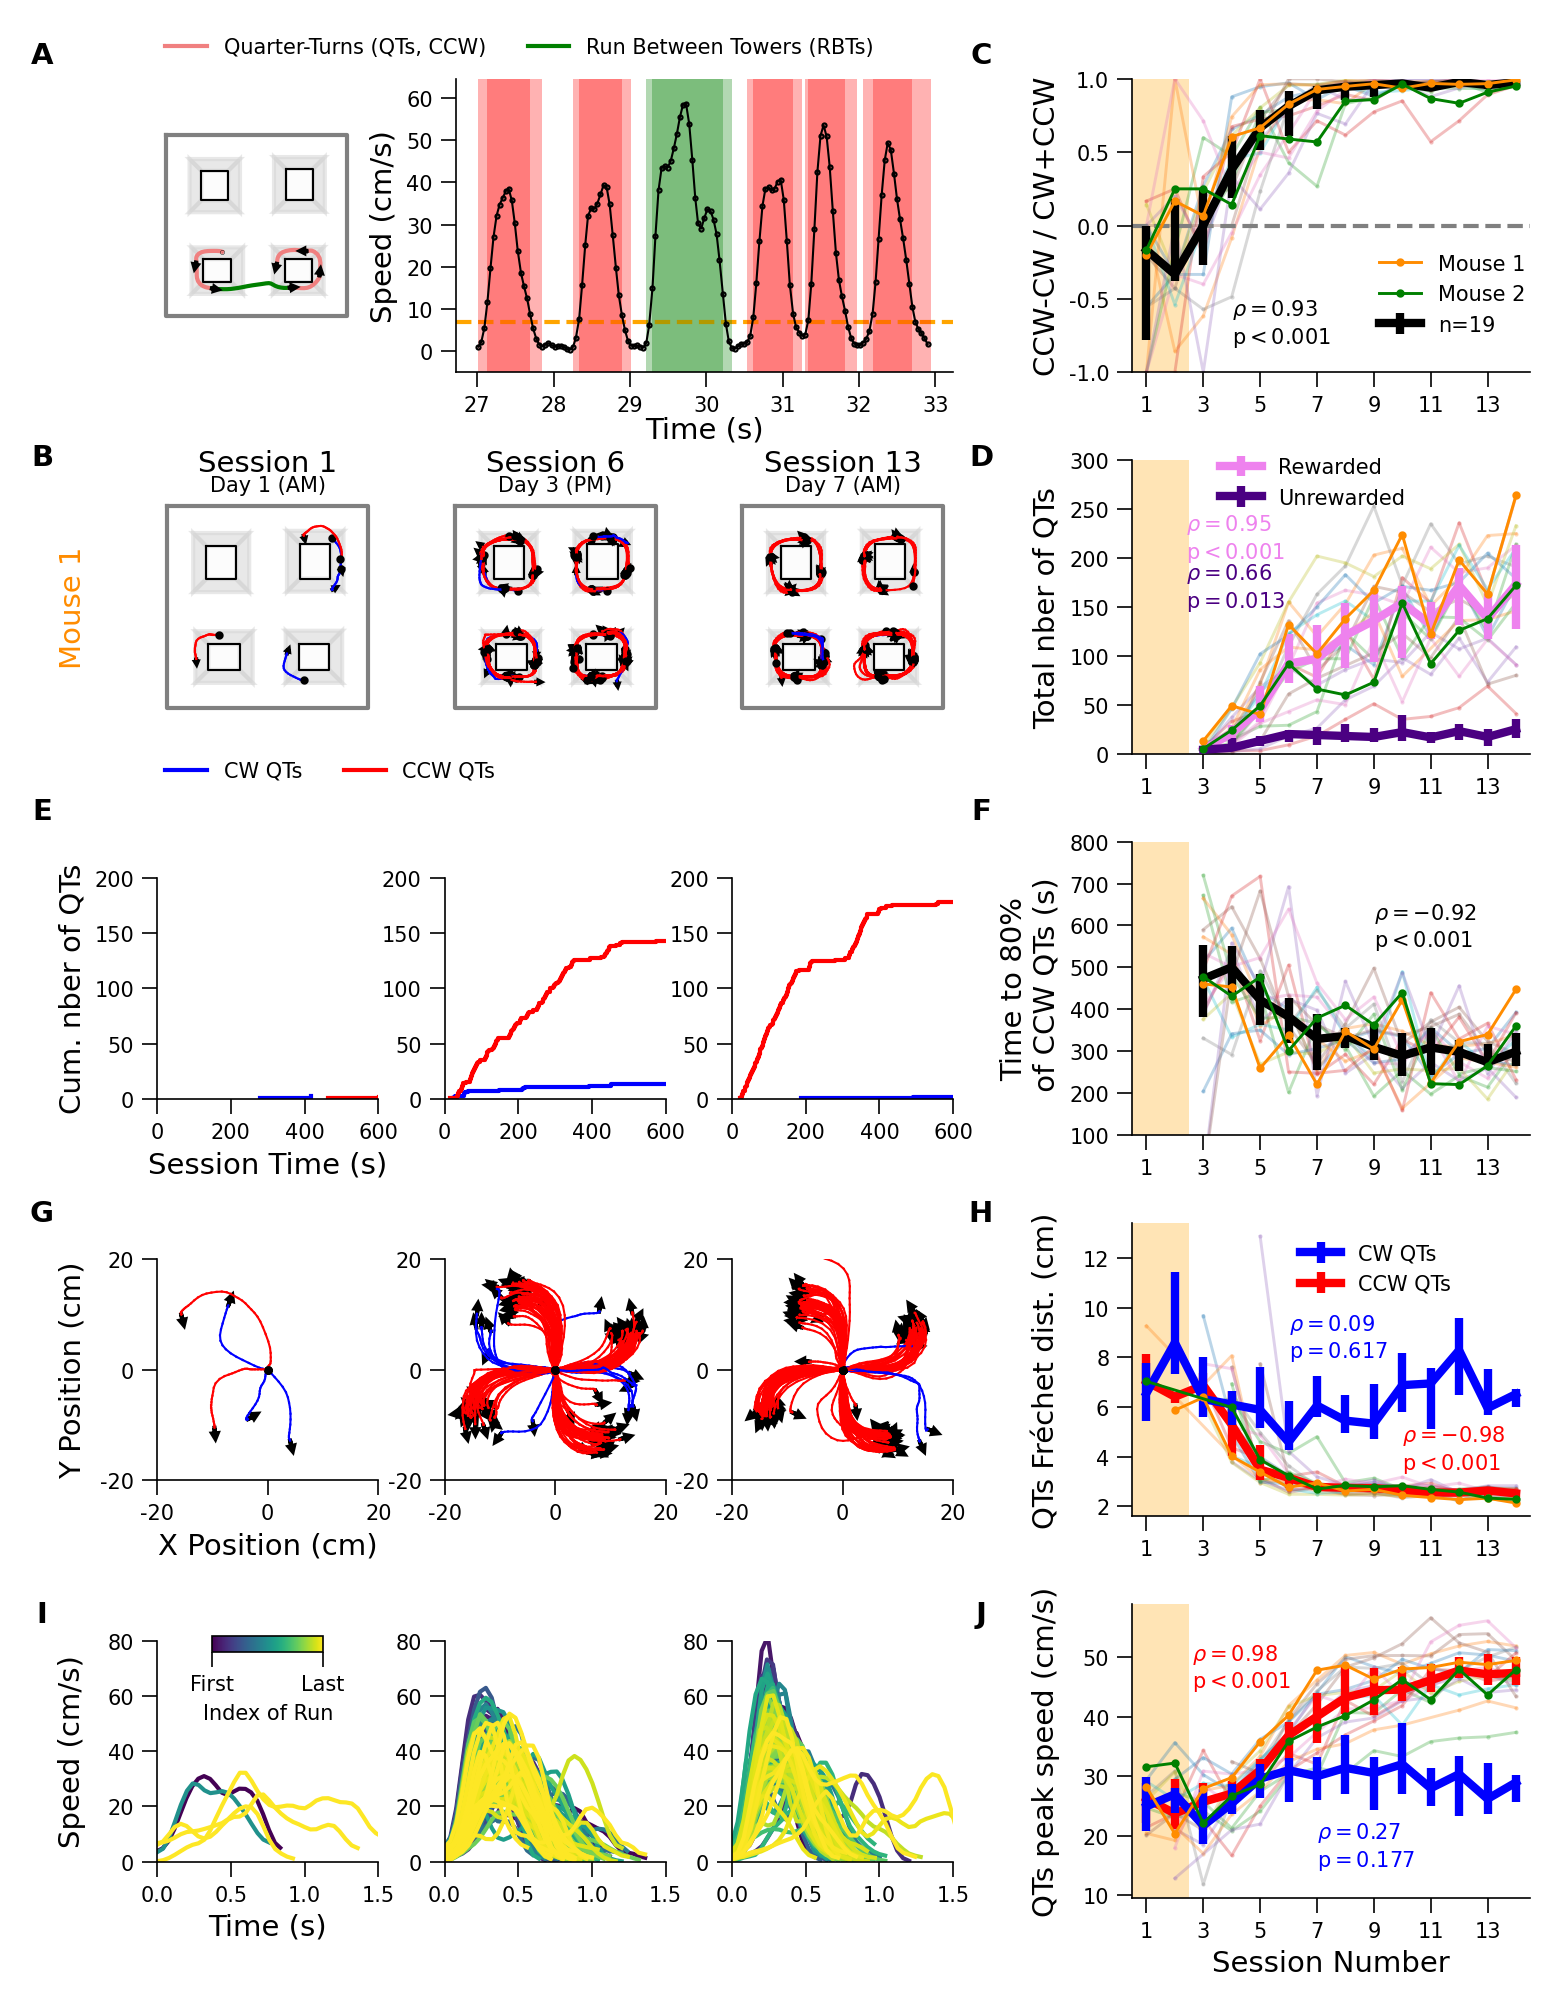

In [26]:
fig=plt.figure(figsize=(cm2inch(15), cm2inch(20)), dpi=300, constrained_layout=False, facecolor='w')
gs = fig.add_gridspec(5, 2 , hspace=0.3, wspace=0.3, width_ratios=(1,0.5))

axes_to_align = []
axes_bis_to_align = []

### Panel A, C ###

row1 = gs[0,0].subgridspec(1, 3, wspace=.5, hspace=.3, width_ratios=[1,1,1])
ax_11 = plt.subplot(row1[0],aspect="equal")
ax_12 = plt.subplot(row1[1:])

row1bis = gs[0,1].subgridspec(1, 1)
ax_1bis = plt.subplot(row1bis[0])

start_index, end_index, trapeze_switch_times = plot_selected_run_epochs(folder_path_example_mouse_bis_to_analyse, index_example_session, first_epoch_to_plot, last_epoch_to_plot, arena_coordinates_cm, ax_11, show_legend=True)
plot_trajectory_speed_chunk(start_index, end_index, traject_time, speeds, run_epochs, clean_run_epochs, ax_12, folder_path_example_mouse_bis_to_analyse, index_example_session)
ax_12.set_xlabel('Time (s)', labelpad=0)

axes_to_align.append(ax_11)

plot_learning_curves(mice_ccw_vs_cw_norm_diff_persession, ax_1bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, mice_to_highlight_labels=['Mouse 1', 'Mouse 2'], show_xlabel = False, xlim=xlim_stats, ylim=[-1,1], ylabel='CCW-CW / CW+CCW', tick_interval=2, index_offset=session_index_offset, main_line_label=f'n={len(mice_to_analyse)}', show_legend=True, legend_loc=(0.6,0.1))

plot_shuffled_spearman_test_res(ax_1bis, (4,-0.8), mice_ccw_vs_cw_norm_diff_persession, 1000, 'increasing', color='black', first_and_last_session_indexes=[1,14])

ax_1bis.axhline(0,linestyle='--', color='grey')

axes_bis_to_align.append(ax_1bis)

fig.text(.06, 0.89, 'A', weight='bold', va='center', ha='center', fontsize=7)
fig.text(.59, 0.89, 'C', weight='bold', va='center', ha='center', fontsize=7)

### Panel B, D ###

row2 = gs[1,0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.1)

row2bis = gs[1,1].subgridspec(1, 1)
ax_2bis = plt.subplot(row2bis[0])

for j in range(len(illustration_sessions_indexes)):

    ax_2 = plt.subplot(row2[j], aspect="equal")

    plot_run_type(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[j], arena_coordinates_cm, ax_2, runtype='run_around_tower', q=4, show_legend= False, legend_loc=(0,-0.2))

    day, period = get_day_and_period(illustration_sessions_indexes[j])
    ax_2.text(0.5, 1.15, f'Session {illustration_sessions_indexes[j] + 1}', va='center', ha='center', transform=ax_2.transAxes, fontsize=7)
    ax_2.text(0.5, 1.1 - 0.05, f'Day {day} ({period})', va='center', ha='center', transform=ax_2.transAxes, fontsize=5)

    if j==0:
        axes_to_align.append(ax_2)
        ax_2.text(-0.38, 0.5, f'Mouse {example_mouse_index+1}', color=illustration_colors[example_mouse_index],rotation=90, va='center', ha='center', transform=ax_2.transAxes, fontsize=7)

plot_learning_curves(mice_rewarded_qts_persession, ax_2bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=True, median_color= 'violet', show_xlabel = False, xlim=xlim_stats, ylim=[0,300], ylabel='Total nber of QTs', main_line_label=f'Rewarded', tick_interval=2, index_offset=session_index_offset, show_legend=True)
plot_learning_curves(mice_unrewarded_qts_persession, ax_2bis, show_individual_mice=False, median_color= 'indigo', show_xlabel = False, xlim=xlim_stats, ylim=[0,300], ylabel='Total nber of QTs', main_line_label=f'Unrewarded', tick_interval=2, index_offset=session_index_offset, show_legend=True, legend_loc=(0.2, 0.81))

plot_shuffled_spearman_test_res(ax_2bis, (2.4,200), mice_rewarded_qts_persession, 1000, 'increasing', color='violet', first_and_last_session_indexes=[2,14])
plot_shuffled_spearman_test_res(ax_2bis, (2.4,150), mice_unrewarded_qts_persession, 1000, 'increasing', color='indigo', first_and_last_session_indexes=[2,14])

axes_bis_to_align.append(ax_2bis)

fig.text(.06, 0.72, 'B', weight='bold', va='center', ha='center', fontsize=7)
fig.text(.59, 0.72, 'D', weight='bold', va='center', ha='center', fontsize=7)

### Panel E, F ###

row3 = gs[2,0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.3)

sessions_to_analyse = sorted([name for name in os.listdir(folder_path_example_mouse_to_analyse)
                                if os.path.isdir(os.path.join(folder_path_example_mouse_to_analyse, name))
                                and name.startswith('MOU')])

for m in range(len(illustration_sessions_indexes)):

    ax_3 = plt.subplot(row3[m], aspect="equal")
    
    show_xlabel= True if m==0 else False
    show_ylabel = True if m==0 else False
    xlim = [0,600]
    ylim = [0,320]

    plot_cumulated_turns_time_profile(folder_path_example_mouse_to_analyse, sessions_to_analyse[illustration_sessions_indexes[m]], ax_3, xlim=xlim, ylim=[0,200] , show_xlabel=show_xlabel, show_ylabel=show_ylabel, show_legend= True if m==0 else False, legend_loc=(0,1.4))
    force_aspect(ax_3,ratio=1)

    if m==0:
        axes_to_align.append(ax_3)

row3bis = gs[2,1].subgridspec(1, 1)
ax_3bis = plt.subplot(row3bis[0])

plot_learning_curves(mice_qts_rewarded_dir_threshold_persession, ax_3bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_xlabel = False, xlim=xlim_stats,ylim=[100,800] ,ylabel='Time to 80%\n of CCW QTs (s)', tick_interval=2, index_offset=session_index_offset, show_legend=False)

plot_shuffled_spearman_test_res(ax_3bis, (9,550), mice_qts_rewarded_dir_threshold_persession, 1000, 'decreasing', color='black', first_and_last_session_indexes=[2,14])

axes_bis_to_align.append(ax_3bis)

fig.text(.06, 0.57, 'E', weight='bold', va='center', ha='center', fontsize=7)
fig.text(.59, 0.57, 'F', weight='bold', va='center', ha='center', fontsize=7)

### Panel G, H ###

row4 = gs[3,0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.3)

for k in range(len(illustration_sessions_indexes)):

    ax_4 = plt.subplot(row4[k], aspect="equal")

    plot_runs_around_towers_origin(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[k], ax_4, q=4, show_xlabel= True if k==0 else False, show_ylabel= True if k==0 else False, show_legend= False, xlim=(-20,20), ylim=(-20,20))
    ax_4.set_xticks([-20, 0, 20])
    ax_4.set_yticks([-20, 0, 20])

    if k==0:

        axes_to_align.append(ax_4)

row4bis = gs[3,1].subgridspec(1, 1)
ax_4bis = plt.subplot(row4bis[0])

plot_learning_curves(overall_cw_turns_frechet_distances_per_session, ax_4bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=False, xlim=xlim_stats, median_color='blue', main_line_label='CW QTs', show_xlabel = False, ylabel='QTs Fréchet dist. (cm)', tick_interval=2, index_offset=session_index_offset, show_legend=False)
plot_learning_curves(overall_ccw_turns_frechet_distances_per_session, ax_4bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=True, xlim=xlim_stats, median_color='red', main_line_label='CCW QTs', show_xlabel = False, ylabel='QTs Fréchet dist. (cm)', tick_interval=2, index_offset=session_index_offset, show_legend=True, legend_loc=(0.4, 0.73))

plot_shuffled_spearman_test_res(ax_4bis, (10,3.5), overall_ccw_turns_frechet_distances_per_session, 1000, 'decreasing', color='red', first_and_last_session_indexes=[1,14])
plot_shuffled_spearman_test_res(ax_4bis, (6,8), overall_cw_turns_frechet_distances_per_session, 1000, 'decreasing', color='blue', first_and_last_session_indexes=[1,14])


axes_bis_to_align.append(ax_4bis)

fig.text(.06, 0.4, 'G', weight='bold', va='center', ha='center', fontsize=7)
fig.text(.59, 0.4, 'H', weight='bold', va='center', ha='center', fontsize=7)

### Panel I, J ###

row5 = gs[4,0].subgridspec(1, len(illustration_sessions_indexes), wspace=.3, hspace=.3)

for l in range(len(illustration_sessions_indexes)):

    ax_5 = plt.subplot(row5[l], aspect="equal")
    
    plot_runs_around_speed_profiles(folder_path_example_mouse_to_analyse, illustration_sessions_indexes[l], ax_5, xlim=(0,1.5), ylim=(0,80), show_xlabel= True if l==0 else False, show_ylabel= True if l==0 else False, show_color_bar= True if l==0 else False)
    
    if l==0:

        axes_to_align.append(ax_5)

    force_aspect(ax_5,ratio=1)

row5bis = gs[4,1].subgridspec(1, 1)
ax_5bis = plt.subplot(row5bis[0])

plot_learning_curves(mice_median_maximum_cw_turn_speed_persession, ax_5bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=False, median_color= 'blue', show_xlabel = False, xlim=xlim_stats, ylabel='QTs peak speed (cm/s)', main_line_label="CW QTs", tick_interval=2, index_offset=session_index_offset, show_legend=False)
plot_learning_curves(mice_median_maximum_ccw_turn_speed_persession, ax_5bis, mice_to_highlight=illustration_mice, highlight_colors=illustration_colors, show_individual_mice=True, median_color= 'red', show_xlabel = True, xlim=xlim_stats, ylabel='QTs peak speed (cm/s)', main_line_label="CCW QTs", tick_interval=2, index_offset=session_index_offset, show_legend=False)

plot_shuffled_spearman_test_res(ax_5bis, (2.6,45), mice_median_maximum_ccw_turn_speed_persession, 1000, 'increasing', color='red', first_and_last_session_indexes=[1,14])
plot_shuffled_spearman_test_res(ax_5bis, (7,15), mice_median_maximum_cw_turn_speed_persession, 1000, 'increasing', color='blue', first_and_last_session_indexes=[1,14])


axes_bis_to_align.append(ax_5bis)

fig.text(.06, 0.23, 'I', weight='bold', va='center', ha='center', fontsize=7)
fig.text(.59, 0.23, 'J', weight='bold', va='center', ha='center', fontsize=7)

fig.align_ylabels(axes_to_align)
fig.align_ylabels(axes_bis_to_align)

# After all plotting is done, right before saving:
fig.tight_layout()
plt.savefig("Figure03.png", facecolor='w', edgecolor='none', format="png", dpi=300)


In [27]:
# Save the figure as a PDF
fig.savefig("Figure03.pdf", format="pdf", bbox_inches='tight', dpi=300)
